# Perbandingan Algoritma LightGBM dan XGBoost untuk Klasifikasi Penyakit Asma
**Penulis:** Benny Dwiyanto — NPM 535220012  
**Program Studi:** Teknik Informatika, Universitas Tarumanagara  
**Dosen Pembimbing:** Tenny Handhayani, S.Kom., M.Kom., Ph.D.
**Dosen Pendamping Pembimbing:** Meirista Wulandari, S.T., M.Eng. Dr
**Tanggal:** 2025

---

## Ringkasan Metodologi

| Aspek | Keterangan |
|---|---|
| **Algoritma** | LightGBM vs XGBoost |
| **Masalah** | Klasifikasi (Asma / Non-Asma) |
| **Penanganan Imbalance** | ADASYN (Adaptive Synthetic Sampling) |
| **Metrik Evaluasi** | Akurasi, Presisi, Recall, F1-Score |
| **Optimasi Threshold** | Precision-Recall Curve |

### Konfigurasi K-Fold
| Dataset | K-Fold | Alasan |
|---|---|---|
| Dataset A — Asma Internasional | **K = 5** | 2.392 sampel, representatif per fold |
| Dataset B — Lokal (RS) | **K = 2** | Hanya ~12 sampel kelas minoritas, K > 2 berisiko fold kosong |

### Alur Notebook *(Direvisi — mengikuti pola pemisahan evaluasi)*
1. Import Library & Konfigurasi Global
2. Load & Eksplorasi Dataset (EDA)
3. Preprocessing (Scaling, Stratified Split, ADASYN)
4. Fungsi Bantu (Model, Threshold, Evaluasi, Waktu)
5. **Pelatihan Final & Evaluasi Data Uji** ← dilakukan lebih dulu
6. **Confusion Matrix & ROC Curve — Data Uji**
7. **Classification Report — Data Uji**
8. **K-Fold Cross Validation — Dataset A (K=5)** ← terpisah
9. **K-Fold Cross Validation — Dataset B (K=2)** ← terpisah
10. Tabel Ringkasan Waktu Komputasi
11. Feature Importance
12. Tabel Perbandingan Final (CV + Data Uji)
13. Pemilihan Model Terbaik & Export
14. Demo Prediksi Pasien
15. Ringkasan Akhir Skripsi

## 1. Import Library & Konfigurasi Global

In [37]:
# Cell ini memuat seluruh library, path, dan konfigurasi global yang dipakai ulang di notebook.
import os
import json
import time
import warnings
warnings.filterwarnings('ignore')

# ─── Numerik & Dataframe ──────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import joblib

# ─── Visualisasi ─────────────────────────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import seaborn as sns

# ─── Scikit-learn ─────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, precision_recall_curve,
    ConfusionMatrixDisplay, RocCurveDisplay
)

# ─── Imbalanced-learn ────────────────────────────────────────────────────────
from imblearn.over_sampling import ADASYN

# ─── Model ───────────────────────────────────────────────────────────────────
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# ─── Konfigurasi Global ───────────────────────────────────────────────────────
RANDOM_STATE = 42
TEST_SIZE    = 0.20
K_FOLD_A     = 5   # Dataset A — Asma Internasional (2392 sampel)
K_FOLD_B     = 5   # Dataset B — Lokal (sampel minoritas sangat sedikit)
MODEL_DIR    = 'models'
os.makedirs(MODEL_DIR, exist_ok=True)

# Style Visualisasi
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'font.family': 'DejaVu Sans'
})
sns.set_theme(style='whitegrid', palette='muted')

print('✅ Library berhasil diimpor.')
print(f'   K-Fold Dataset A (Asma Internasional) : K = {K_FOLD_A}')
print(f'   K-Fold Dataset B (Lokal / RS)         : K = {K_FOLD_B}')
print(f'   Model akan disimpan ke folder: {MODEL_DIR}/')

✅ Library berhasil diimpor.
   K-Fold Dataset A (Asma Internasional) : K = 5
   K-Fold Dataset B (Lokal / RS)         : K = 5
   Model akan disimpan ke folder: models/


## 2. Load & Eksplorasi Dataset (EDA)

In [38]:
# ── Dataset A — Asthma Asthma Disease Dataset 
df_asthma = pd.read_csv('data/asthma_disease_data.csv')
FEATURES_A = [
    'Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI', 'Smoking',
    'PhysicalActivity', 'DietQuality', 'SleepQuality',
    'PollutionExposure', 'PollenExposure', 'DustExposure',
    'PetAllergy', 'FamilyHistoryAsthma', 'HistoryOfAllergies',
    'Eczema', 'HayFever', 'GastroesophagealReflux',
    'LungFunctionFEV1', 'LungFunctionFVC',
    'Wheezing', 'ShortnessOfBreath', 'ChestTightness',
    'Coughing', 'NighttimeSymptoms', 'ExerciseInduced'
]
TARGET_A = 'Diagnosis'
LABELS_A  = {0: 'Non-Asma', 1: 'Asma'}

# ── Dataset B — Rumah sakit islam jakarta cempaka putih
df_local = pd.read_excel('data/dataset_new.backup_before_fix.xlsx')
FEATURES_B = [
    'umur', 'tb', 'bb', 'jenis kelamin', 'Batuk', 'pilek',
    'demam', 'sesak', 'mengi', 'mual', 'lemas', 'nyeri dada',
    'nyeri uluh hati', 'pusing', 'dahak', 'napas berat',
    'riwayat keluarga', 'alergi', 'penyakit bawaan', 'dm',
    'penyakit_tb', 'gerd', 'merokok', 'populasi udara',
    'tidur', 'aktivitas', 'mudah lelah'
]
TARGET_B = 'diagnosis'
LABELS_B  = {0: 'Negatif', 1: 'Positif'}

print('=== DATASET A — Asthma Disease Dataset  ===')
vc_a = df_asthma[TARGET_A].value_counts()
print(f'  Shape          : {df_asthma.shape}')
print(f'  Missing Values : {df_asthma.isnull().sum().sum()}')
print(f'  Kelas 0 (Non)  : {vc_a[0]} ({vc_a[0]/len(df_asthma)*100:.1f}%)')
print(f'  Kelas 1 (Asma) : {vc_a[1]} ({vc_a[1]/len(df_asthma)*100:.1f}%)')
print(f'  Rasio imbalance: 1 : {vc_a[0]/vc_a[1]:.1f}')
print(f'  K-Fold         : K = {K_FOLD_A}')
print()
print('=== DATASET B — Rumah Sakit Islam Jakarta Cempaka Putih ===')
vc_b = df_local[TARGET_B].value_counts()
print(f'  Shape          : {df_local.shape}')
print(f'  Missing Values : {df_local.isnull().sum().sum()}')
print(f'  Kelas 0 (Neg)  : {vc_b[0]} ({vc_b[0]/len(df_local)*100:.1f}%)')
print(f'  Kelas 1 (Pos)  : {vc_b[1]} ({vc_b[1]/len(df_local)*100:.1f}%)')
print(f'  Rasio imbalance: 1 : {vc_b[1]/vc_b[0]:.1f}')
print(f'  K-Fold         : K = {K_FOLD_B}  (minoritas = {min(vc_b)} sampel, K > 2 berisiko)')

=== DATASET A — Asthma Disease Dataset  ===
  Shape          : (2392, 29)
  Missing Values : 0
  Kelas 0 (Non)  : 2268 (94.8%)
  Kelas 1 (Asma) : 124 (5.2%)
  Rasio imbalance: 1 : 18.3
  K-Fold         : K = 5

=== DATASET B — Rumah Sakit Islam Jakarta Cempaka Putih ===
  Shape          : (219, 28)
  Missing Values : 0
  Kelas 0 (Neg)  : 12 (5.5%)
  Kelas 1 (Pos)  : 207 (94.5%)
  Rasio imbalance: 1 : 17.2
  K-Fold         : K = 5  (minoritas = 12 sampel, K > 2 berisiko)


In [39]:
# ── 2.1 Statistik Deskriptif Dataset A 
print('=== STATISTIK DESKRIPTIF — DATASET A ===')
df_asthma.describe().T.style.background_gradient(cmap='Blues', subset=['mean','std'])

=== STATISTIK DESKRIPTIF — DATASET A ===


,count,mean,std,min,25%,50%,75%,max
PatientID,2392.000000,6229.500000,690.655244,5034.000000,5631.750000,6229.500000,6827.250000,7425.000000
Age,2392.000000,42.137960,21.606655,5.000000,23.000000,42.000000,61.000000,79.000000
Gender,2392.000000,0.493311,0.500060,0.000000,0.000000,0.000000,1.000000,1.000000
Ethnicity,2392.000000,0.669732,0.986120,0.000000,0.000000,0.000000,1.000000,3.000000
EducationLevel,2392.000000,1.307274,0.898242,0.000000,1.000000,1.000000,2.000000,3.000000
BMI,2392.000000,27.244877,7.201628,15.031803,20.968313,27.052202,33.555903,39.985611
Smoking,2392.000000,0.141722,0.348838,0.000000,0.000000,0.000000,0.000000,1.000000
PhysicalActivity,2392.000000,5.051786,2.903574,0.001740,2.578333,5.016881,7.540234,9.995809
DietQuality,2392.000000,5.022867,2.909980,0.003031,2.432043,5.115383,7.544216,9.999904
SleepQuality,2392.000000,7.019012,1.732475,4.001437,5.498500,6.975839,8.526950,9.996235


In [40]:
# ── 2.2 Statistik Deskriptif Dataset B ───────────────────────────────────────
print('=== STATISTIK DESKRIPTIF — DATASET B ===')
df_local.describe().T.style.background_gradient(cmap='Oranges', subset=['mean','std'])

=== STATISTIK DESKRIPTIF — DATASET B ===


,count,mean,std,min,25%,50%,75%,max
umur,219.000000,50.337900,18.254696,1.000000,39.000000,54.000000,64.000000,85.000000
tb,219.000000,154.961187,17.034560,0.000000,151.500000,158.000000,162.000000,182.000000
bb,219.000000,63.371918,17.565890,0.000000,54.000000,64.000000,74.000000,106.000000
jenis kelamin,219.000000,0.296804,0.457896,0.000000,0.000000,0.000000,1.000000,1.000000
Batuk,219.000000,0.648402,0.478563,0.000000,0.000000,1.000000,1.000000,1.000000
pilek,219.000000,0.155251,0.362974,0.000000,0.000000,0.000000,0.000000,1.000000
demam,219.000000,0.191781,0.394604,0.000000,0.000000,0.000000,0.000000,1.000000
sesak,219.000000,0.589041,0.493135,0.000000,0.000000,1.000000,1.000000,1.000000
mengi,219.000000,0.100457,0.301297,0.000000,0.000000,0.000000,0.000000,1.000000
mual,219.000000,0.036530,0.188034,0.000000,0.000000,0.000000,0.000000,1.000000


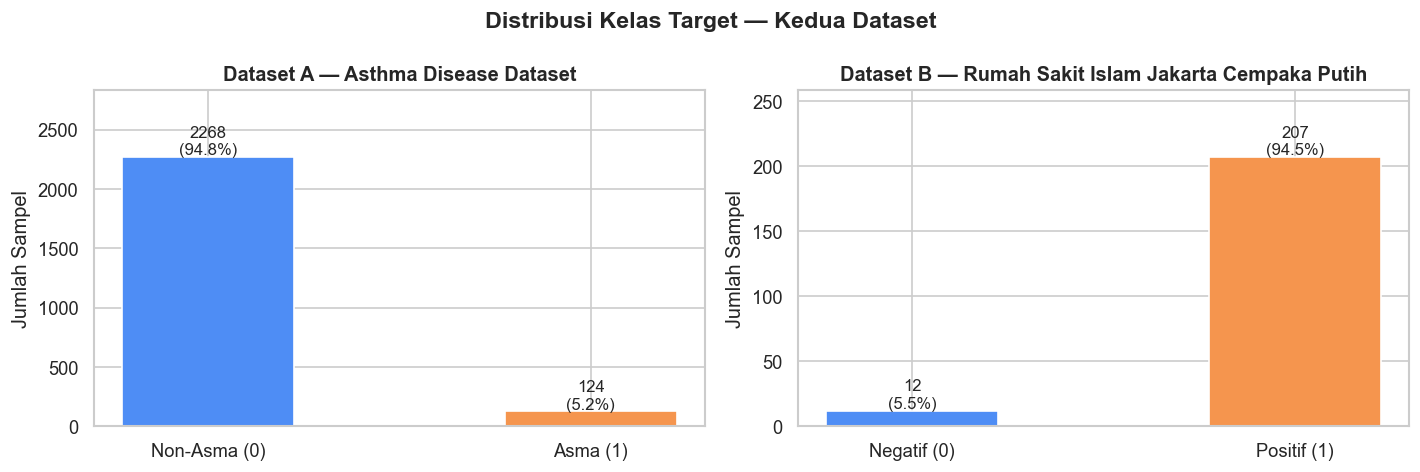

✅ Disimpan: 01_distribusi_kelas.png


In [41]:
# ── 2.3 Visualisasi Distribusi Kelas ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (title, vc, labels, total) in zip(axes, [
    ('Dataset A — Asthma Disease Dataset', vc_a, ['Non-Asma (0)', 'Asma (1)'], len(df_asthma)),
    ('Dataset B — Rumah Sakit Islam Jakarta Cempaka Putih', vc_b, ['Negatif (0)', 'Positif (1)'], len(df_local))
]):
    vals = [vc[0], vc[1]]
    bars = ax.bar(labels, vals, color=['#4e8df5', '#f5954e'], width=0.45, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                f'{v}\n({v/total*100:.1f}%)', ha='center', fontsize=10)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Jumlah Sampel')
    ax.set_ylim(0, max(vals) * 1.25)
plt.suptitle('Distribusi Kelas Target — Kedua Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/01_distribusi_kelas.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Disimpan: 01_distribusi_kelas.png')

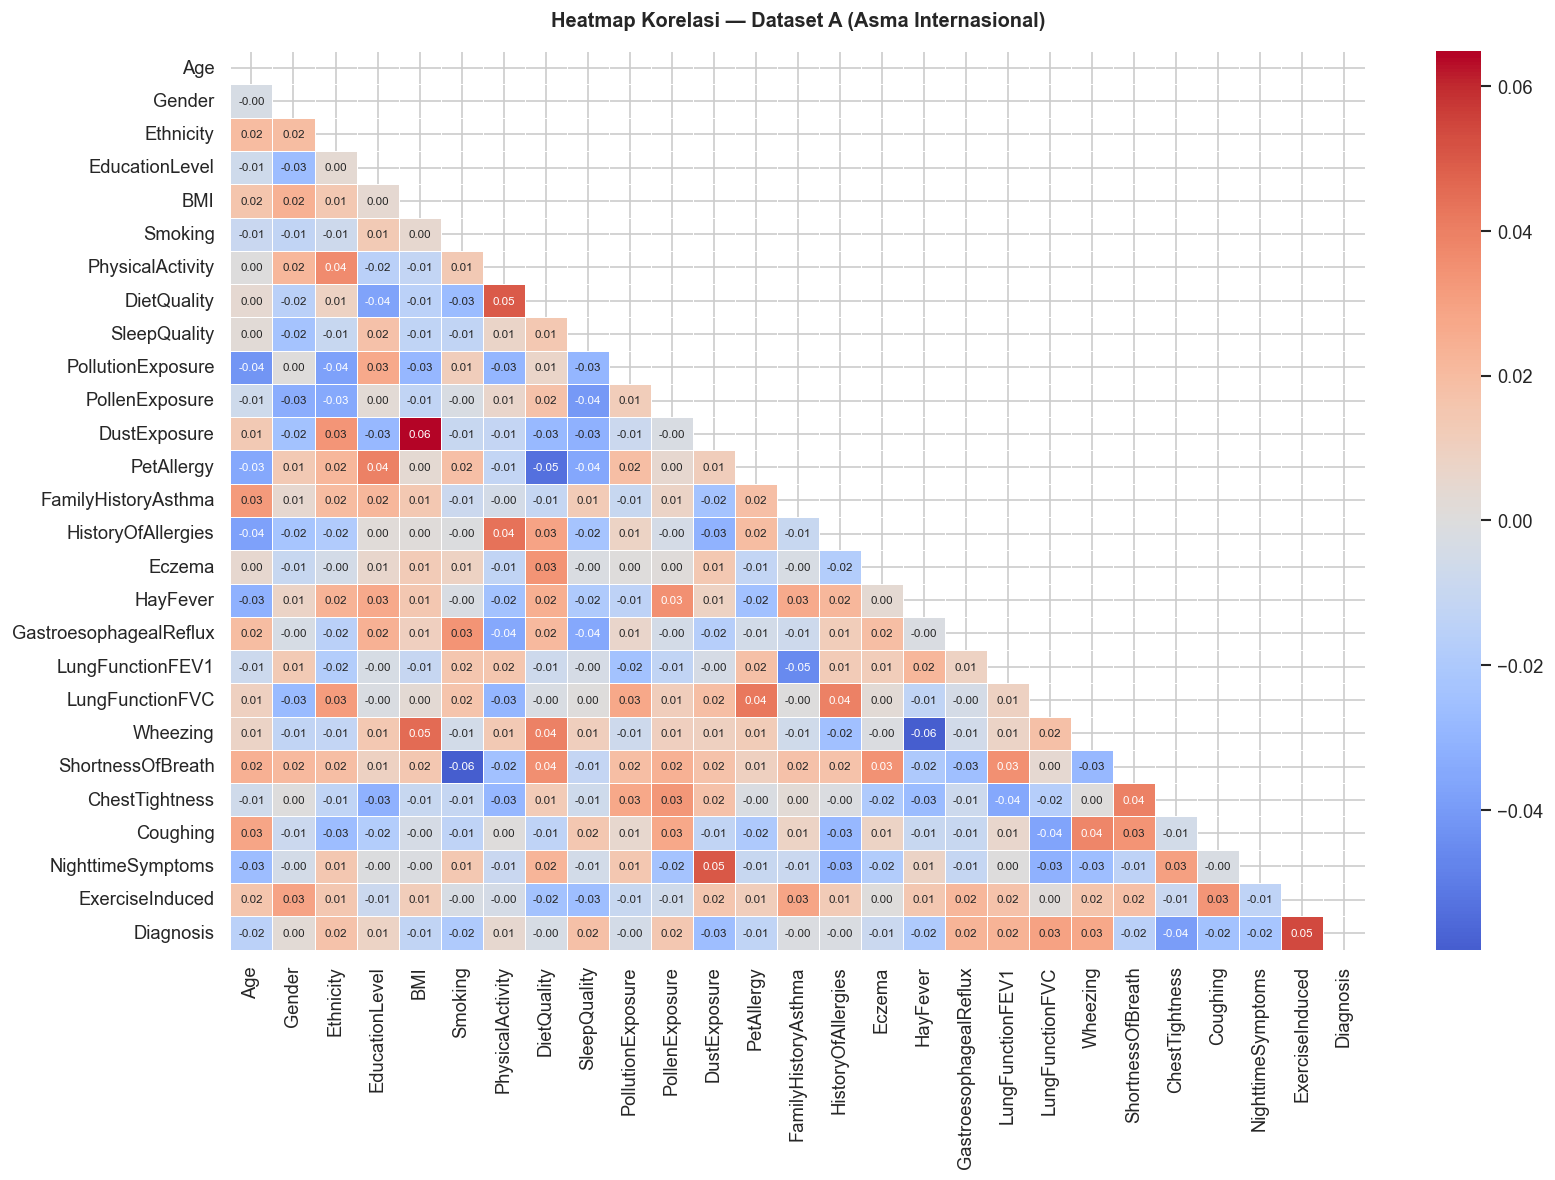

✅ Disimpan: heatmap_asthma.png


In [42]:
# ── 2.4 Heatmap Korelasi Dataset A ───────────────────────────────────────────
drop_cols_a = ['PatientID', 'DoctorInCharge']
df_a_clean = df_asthma.drop(columns=[c for c in drop_cols_a if c in df_asthma.columns])

fig, ax = plt.subplots(figsize=(14, 10))
corr = df_a_clean.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.3, ax=ax, annot_kws={'size': 7})
ax.set_title('Heatmap Korelasi — Dataset A (Asma Internasional)', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/heatmap_asthma.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Disimpan: heatmap_asthma.png')

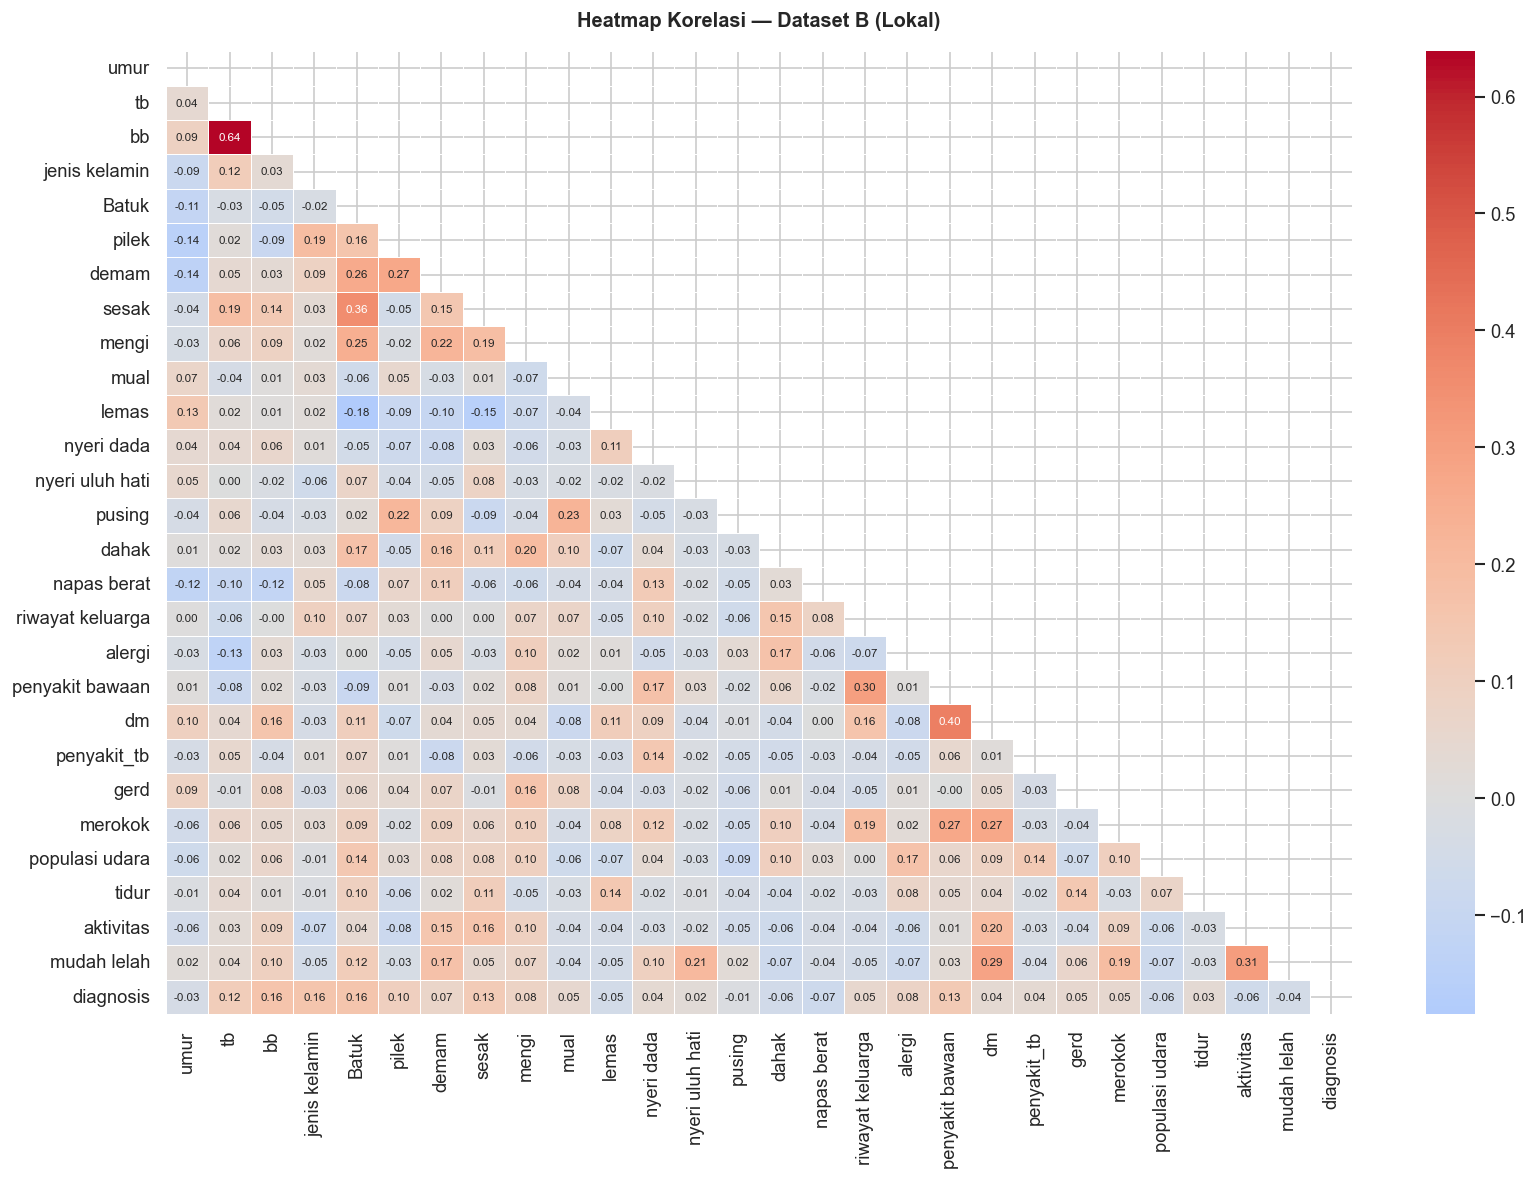

✅ Disimpan: heatmap_local.png


In [43]:
# ── 2.5 Heatmap Korelasi Dataset B ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 10))
corr_b = df_local.corr()
mask_b = np.triu(np.ones_like(corr_b, dtype=bool))
sns.heatmap(corr_b, mask=mask_b, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.3, ax=ax, annot_kws={'size': 7})
ax.set_title('Heatmap Korelasi — Dataset B (Lokal)', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/heatmap_local.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Disimpan: heatmap_local.png')

## 3. Preprocessing & ADASYN

In [44]:
# Fungsi ini menyiapkan data dasar: pilih fitur-target, scaling, lalu split train-test terstratifikasi.
def preprocess_and_split(df, features, target, test_size=0.20, random_state=42):
    """StandardScaler + Stratified Train-Test Split. Return dict lengkap."""
    X = df[features].values
    y = df[target].values
    scaler = StandardScaler()
    X_sc   = scaler.fit_transform(X)
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_sc, y, test_size=test_size, random_state=random_state, stratify=y
    )
    return {'X_train': X_tr, 'X_test': X_te,
            'y_train': y_tr, 'y_test': y_te,
            'scaler': scaler}


def apply_adasyn(X_train, y_train, ds_name, random_state=42):
    """
    ADASYN dengan n_neighbors adaptif.
    n_neighbors = min(5, jumlah_minoritas - 1) untuk menghindari error
    pada dataset dengan kelas minoritas sangat kecil (seperti Dataset B).
    """
    counts  = dict(zip(*np.unique(y_train, return_counts=True)))
    minority = min(counts.values())
    n_nb    = max(1, min(5, minority - 1))
    print(f'  [{ds_name}] Sebelum ADASYN : {counts} | n_neighbors={n_nb}')
    adasyn  = ADASYN(sampling_strategy='minority',
                     n_neighbors=n_nb, random_state=random_state)
    X_res, y_res = adasyn.fit_resample(X_train, y_train)
    counts_after = dict(zip(*np.unique(y_res, return_counts=True)))
    print(f'  [{ds_name}] Sesudah ADASYN : {counts_after}')
    return X_res, y_res


# ── Proses kedua dataset ──────────────────────────────────────────────────────
data_A = preprocess_and_split(df_asthma, FEATURES_A, TARGET_A)
data_B = preprocess_and_split(df_local,  FEATURES_B, TARGET_B)

print('\n=== ADASYN — Global (untuk pelatihan final) ===')
X_A_res, y_A_res = apply_adasyn(data_A['X_train'], data_A['y_train'], 'Dataset A')
X_B_res, y_B_res = apply_adasyn(data_B['X_train'], data_B['y_train'], 'Dataset B')

print(f'\n  Split Dataset A → Train: {len(data_A["y_train"])}, Test: {len(data_A["y_test"])}')
print(f'  Split Dataset B → Train: {len(data_B["y_train"])}, Test: {len(data_B["y_test"])}')


=== ADASYN — Global (untuk pelatihan final) ===
  [Dataset A] Sebelum ADASYN : {0: 1814, 1: 99} | n_neighbors=5
  [Dataset A] Sesudah ADASYN : {0: 1814, 1: 1822}
  [Dataset B] Sebelum ADASYN : {0: 10, 1: 165} | n_neighbors=5
  [Dataset B] Sesudah ADASYN : {0: 165, 1: 165}

  Split Dataset A → Train: 1913, Test: 479
  Split Dataset B → Train: 175, Test: 44


## 3.1 Tambahan Revisi — Pemeriksaan Pembagian Data Latih dan Testing

Bagian ini ditambahkan untuk memenuhi catatan revisi terkait pemeriksaan kembali pembagian data latih dan data testing, serta membandingkan jumlah data kelas asma dan tidak asma pada masing-masing dataset. Pemeriksaan dilakukan pada data training, data testing, dan data training setelah penanganan ketidakseimbangan kelas menggunakan ADASYN.

In [45]:
# Tambahan revisi: pemeriksaan distribusi kelas pada data latih dan data testing
# Catatan: cell ini tidak mengubah proses training/model, hanya menampilkan ringkasan distribusi data.

def label_asma(label):
    """Mengubah label numerik menjadi label kelas yang mudah dibaca."""
    try:
        label_int = int(label)
        return 'Asma' if label_int == 1 else 'Tidak Asma'
    except Exception:
        return str(label)

def buat_tabel_distribusi_split(y_values, dataset_name, bagian):
    """Membuat tabel distribusi kelas untuk bagian data tertentu."""
    counts = pd.Series(y_values).value_counts().sort_index()
    total = counts.sum()
    rows = []
    for kelas, jumlah in counts.items():
        rows.append({
            'Dataset': dataset_name,
            'Bagian Data': bagian,
            'Kelas': label_asma(kelas),
            'Jumlah': int(jumlah),
            'Persentase (%)': round((jumlah / total) * 100, 2)
        })
    return rows

rows_split = []

# Dataset A
rows_split += buat_tabel_distribusi_split(data_A['y_train'], 'Dataset A', 'Data Latih Sebelum ADASYN')
rows_split += buat_tabel_distribusi_split(data_A['y_test'],  'Dataset A', 'Data Testing')
rows_split += buat_tabel_distribusi_split(y_A_res,           'Dataset A', 'Data Latih Setelah ADASYN')

# Dataset B
rows_split += buat_tabel_distribusi_split(data_B['y_train'], 'Dataset B', 'Data Latih Sebelum ADASYN')
rows_split += buat_tabel_distribusi_split(data_B['y_test'],  'Dataset B', 'Data Testing')
rows_split += buat_tabel_distribusi_split(y_B_res,           'Dataset B', 'Data Latih Setelah ADASYN')

df_distribusi_split = pd.DataFrame(rows_split)

print('=' * 90)
print('  PEMERIKSAAN PEMBAGIAN DATA LATIH DAN TESTING')
print('=' * 90)
print(df_distribusi_split.to_string(index=False))

# Simpan tabel untuk kebutuhan laporan skripsi
df_distribusi_split.to_csv(f'{MODEL_DIR}/tabel_distribusi_train_test_asma_non_asma.csv',
                           index=False, encoding='utf-8-sig')
print('\n  OK Tabel disimpan: tabel_distribusi_train_test_asma_non_asma.csv')

df_distribusi_split.style \
    .set_caption('Distribusi Kelas Asma dan Tidak Asma pada Data Latih dan Testing') \
    .set_properties(**{'text-align': 'center', 'font-size': '12px'})

  PEMERIKSAAN PEMBAGIAN DATA LATIH DAN TESTING
  Dataset               Bagian Data      Kelas  Jumlah  Persentase (%)
Dataset A Data Latih Sebelum ADASYN Tidak Asma    1814           94.82
Dataset A Data Latih Sebelum ADASYN       Asma      99            5.18
Dataset A              Data Testing Tidak Asma     454           94.78
Dataset A              Data Testing       Asma      25            5.22
Dataset A Data Latih Setelah ADASYN Tidak Asma    1814           49.89
Dataset A Data Latih Setelah ADASYN       Asma    1822           50.11
Dataset B Data Latih Sebelum ADASYN Tidak Asma      10            5.71
Dataset B Data Latih Sebelum ADASYN       Asma     165           94.29
Dataset B              Data Testing Tidak Asma       2            4.55
Dataset B              Data Testing       Asma      42           95.45
Dataset B Data Latih Setelah ADASYN Tidak Asma     165           50.00
Dataset B Data Latih Setelah ADASYN       Asma     165           50.00

  OK Tabel disimpan: tabel_di

,Dataset,Bagian Data,Kelas,Jumlah,Persentase (%)
0,Dataset A,Data Latih Sebelum ADASYN,Tidak Asma,1814,94.820000
1,Dataset A,Data Latih Sebelum ADASYN,Asma,99,5.180000
2,Dataset A,Data Testing,Tidak Asma,454,94.780000
3,Dataset A,Data Testing,Asma,25,5.220000
4,Dataset A,Data Latih Setelah ADASYN,Tidak Asma,1814,49.890000
5,Dataset A,Data Latih Setelah ADASYN,Asma,1822,50.110000
6,Dataset B,Data Latih Sebelum ADASYN,Tidak Asma,10,5.710000
7,Dataset B,Data Latih Sebelum ADASYN,Asma,165,94.290000
8,Dataset B,Data Testing,Tidak Asma,2,4.550000
9,Dataset B,Data Testing,Asma,42,95.450000


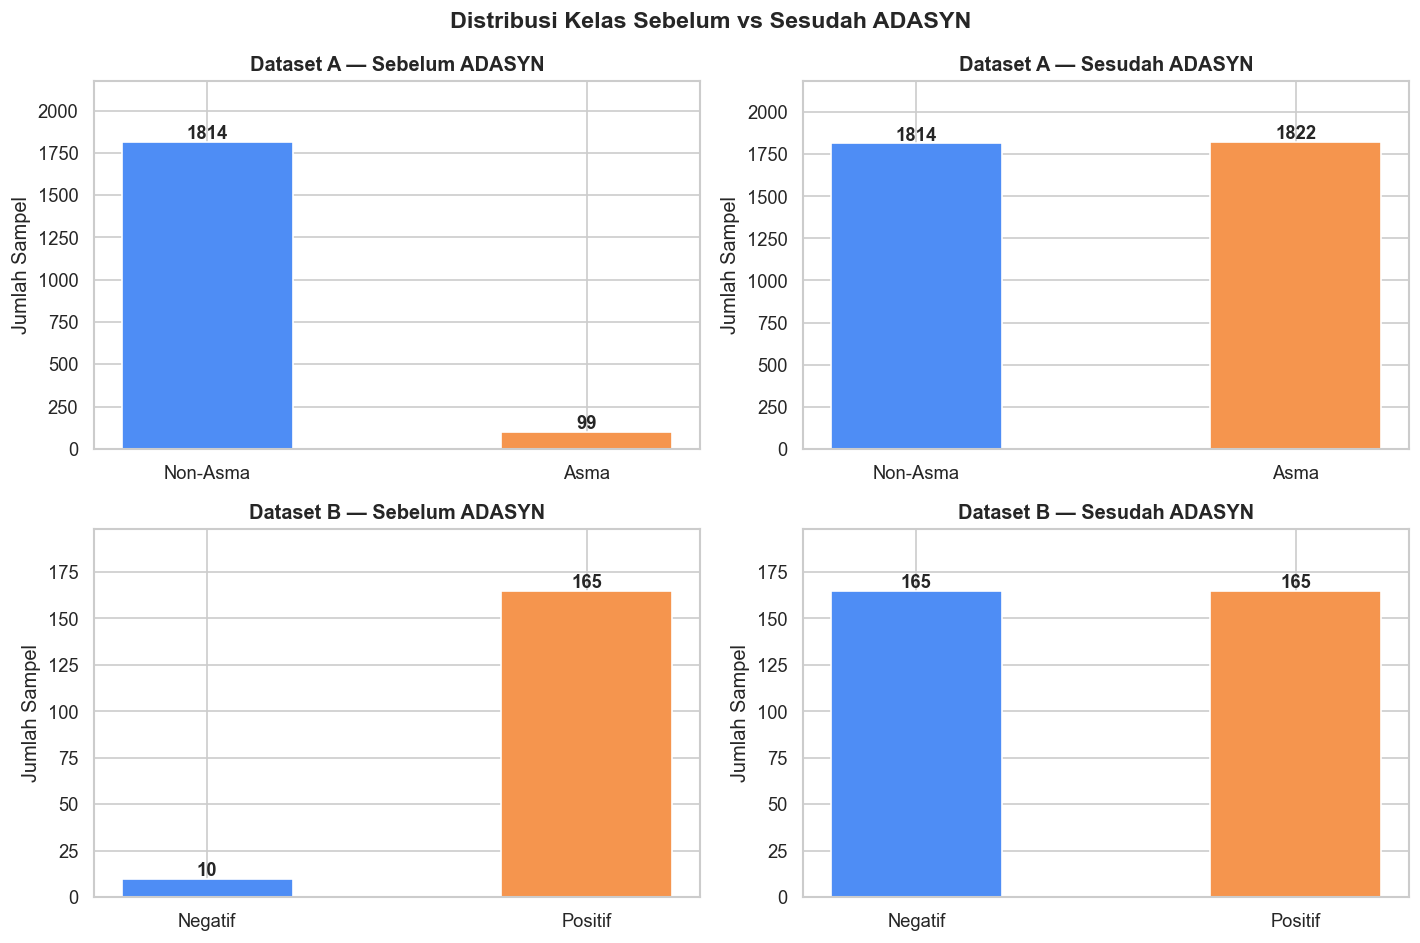

✅ Disimpan: 02_adasyn_before_after.png


In [46]:
# ── Visualisasi Sebelum vs Sesudah ADASYN ────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

datasets = [
    ('Dataset A — Sebelum ADASYN', data_A['y_train'],   ['Non-Asma','Asma'],  axes[0,0]),
    ('Dataset A — Sesudah ADASYN', y_A_res,              ['Non-Asma','Asma'],  axes[0,1]),
    ('Dataset B — Sebelum ADASYN', data_B['y_train'],   ['Negatif','Positif'], axes[1,0]),
    ('Dataset B — Sesudah ADASYN', y_B_res,              ['Negatif','Positif'], axes[1,1]),
]

for title, y, labels, ax in datasets:
    vc = dict(zip(*np.unique(y, return_counts=True)))
    vals = [vc.get(0,0), vc.get(1,0)]
    bars = ax.bar(labels, vals, color=['#4e8df5','#f5954e'], width=0.45, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                str(v), ha='center', fontsize=11, fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Jumlah Sampel')
    ax.set_ylim(0, max(vals) * 1.2)

plt.suptitle('Distribusi Kelas Sebelum vs Sesudah ADASYN', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/02_adasyn_before_after.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Disimpan: 02_adasyn_before_after.png')

## 4. Fungsi Bantu — Model, Threshold, Evaluasi, Waktu

In [47]:
# Fungsi ini membuat dua kandidat model utama dengan penyesuaian untuk data tidak seimbang.
def build_models(y_train):
    """Instansiasi LightGBM dan XGBoost dengan penanganan imbalance."""
    counts = dict(zip(*np.unique(y_train, return_counts=True)))
    spw    = counts.get(0, 1) / max(counts.get(1, 1), 1)

    lgbm = LGBMClassifier(
        n_estimators=500, learning_rate=0.05, num_leaves=63,
        min_child_samples=5, subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=0.1,
        class_weight='balanced',
        random_state=RANDOM_STATE, verbose=-1
    )
    xgb = XGBClassifier(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        min_child_weight=3, subsample=0.8, colsample_bytree=0.8,
        gamma=0.1, reg_alpha=0.1, reg_lambda=1.0,
        scale_pos_weight=spw,
        eval_metric='logloss',
        random_state=RANDOM_STATE, verbosity=0
    )
    return lgbm, xgb


def find_best_threshold(model, X_val, y_val):
    """Threshold optimal via Precision-Recall Curve (maximize F1)."""
    proba = model.predict_proba(X_val)[:, 1]
    prec, rec, thr = precision_recall_curve(y_val, proba)
    f1s = []
    for p, r in zip(prec[:-1], rec[:-1]):
        f1s.append(2*p*r/(p+r) if (p+r) > 0 else 0.0)
    best_idx = int(np.argmax(f1s))
    return float(thr[best_idx]), float(f1s[best_idx]), prec, rec, thr


def compute_metrics(y_true, y_pred, y_proba):
    """Hitung accuracy, precision, recall, f1-score (weighted) dan ROC-AUC."""
    try:
        auc = roc_auc_score(y_true, y_proba)
    except Exception:
        auc = 0.0
    return {
        'accuracy'  : float(accuracy_score(y_true, y_pred)),
        'precision' : float(precision_score(y_true, y_pred, average='weighted', zero_division=0)),
        'recall'    : float(recall_score(y_true, y_pred, average='weighted', zero_division=0)),
        'f1'        : float(f1_score(y_true, y_pred, average='weighted', zero_division=0)),
        'roc_auc'   : float(auc),
    }


print('✅ Fungsi bantu siap.')

✅ Fungsi bantu siap.


## 5. Pelatihan Final & Evaluasi Data Uji

In [48]:
# Cell ini berisi pipeline pelatihan final yang nanti dipakai untuk evaluasi data uji dan export model.
# Cell ini melatih model final pada seluruh data training yang sudah di-resample ADASYN.
# Evaluasi dilakukan pada data uji (test set) yang belum pernah dilihat model.
# Threshold optimal dicari via Precision-Recall Curve pada data uji.
# Alur ini DIPISAHKAN dari cross validation agar evaluasi lebih transparan.

def train_and_evaluate_test(X_res, y_res, X_test, y_test,
                             model_name, dataset_name):
    """
    Pelatihan final + evaluasi pada data uji.
    Tidak ada cross validation di sini — hanya training final dan test evaluation.

    Return dict berisi model, threshold, metrik test, proba, cm, dan timing.
    """
    print(f"\n{'─'*60}")
    print(f'  [PELATIHAN FINAL] {model_name} — {dataset_name}')
    print(f"{'─'*60}")

    # ── Instansiasi & Training Final ─────────────────────────────────────────
    lgbm_final, xgb_final = build_models(y_res)
    model_final = lgbm_final if 'LightGBM' in model_name else xgb_final

    t0 = time.perf_counter()
    model_final.fit(X_res, y_res)
    final_train_time = time.perf_counter() - t0

    # ── Threshold Optimal via PR-Curve ────────────────────────────────────────
    threshold_opt, _, _, _, _ = find_best_threshold(model_final, X_test, y_test)

    # ── Evaluasi Test Set ─────────────────────────────────────────────────────
    t0 = time.perf_counter()
    proba_test = model_final.predict_proba(X_test)[:, 1]
    test_pred_time = time.perf_counter() - t0

    y_pred_test  = (proba_test >= threshold_opt).astype(int)
    test_metrics = compute_metrics(y_test, y_pred_test, proba_test)
    cm = confusion_matrix(y_test, y_pred_test)

    print(f'  Waktu Training Final  : {final_train_time:.3f}s')
    print(f'  Waktu Prediksi Test   : {test_pred_time*1000:.2f}ms')
    print(f'  Threshold Optimal     : {threshold_opt:.4f}')
    print(f"  {'─'*50}")
    print(f"  TEST  Accuracy    : {test_metrics['accuracy']:.4f}")
    print(f"  TEST  Precision   : {test_metrics['precision']:.4f}")
    print(f"  TEST  Recall      : {test_metrics['recall']:.4f}")
    print(f"  TEST  F1-Score    : {test_metrics['f1']:.4f}")
    print(f"  TEST  ROC-AUC     : {test_metrics['roc_auc']:.4f}")

    timing_test = {
        'final_train_s' : round(final_train_time, 3),
        'test_pred_s'   : round(test_pred_time, 6),
    }

    return {
        'model_name'  : model_name,
        'dataset_name': dataset_name,
        'model'       : model_final,
        'threshold'   : threshold_opt,
        'test_metrics': test_metrics,
        'proba_test'  : proba_test,
        'cm'          : cm,
        'timing_test' : timing_test,
        # Placeholder — akan diisi setelah CV dijalankan
        'cv_summary'  : {},
        'fold_results': [],
        'k'           : None,
        'timing'      : {},
    }


print('✅ Fungsi train_and_evaluate_test siap.')

✅ Fungsi train_and_evaluate_test siap.


In [49]:
# ── Dataset A — Asma desease dataset ───────────────────────────────────────────
print('=' * 65)
print('  PELATIHAN FINAL — DATASET A asthma disease dataset')
print('  Evaluasi dilakukan pada data uji (test set)')
print('=' * 65)

res_lgbm_A = train_and_evaluate_test(
    X_A_res, y_A_res,
    data_A['X_test'], data_A['y_test'],
    'LightGBM', 'Dataset A'
)

res_xgb_A = train_and_evaluate_test(
    X_A_res, y_A_res,
    data_A['X_test'], data_A['y_test'],
    'XGBoost', 'Dataset A'
)

scaler_A = data_A['scaler']

# ── Dataset B — Lokal ─────────────────────────────────────────────────────────
print('\n' + '=' * 65)
print('  PELATIHAN FINAL — DATASET B rumah sakit islam jakarta cempaka putih')
print('  Evaluasi dilakukan pada data uji (test set)')
print('=' * 65)

res_lgbm_B = train_and_evaluate_test(
    X_B_res, y_B_res,
    data_B['X_test'], data_B['y_test'],
    'LightGBM', 'Dataset B'
)

res_xgb_B = train_and_evaluate_test(
    X_B_res, y_B_res,
    data_B['X_test'], data_B['y_test'],
    'XGBoost', 'Dataset B'
)

scaler_B = data_B['scaler']

print('\n✅ Pelatihan final & evaluasi data uji selesai untuk semua model.')

  PELATIHAN FINAL — DATASET A asthma disease dataset
  Evaluasi dilakukan pada data uji (test set)

────────────────────────────────────────────────────────────
  [PELATIHAN FINAL] LightGBM — Dataset A
────────────────────────────────────────────────────────────
  Waktu Training Final  : 0.490s
  Waktu Prediksi Test   : 3.07ms
  Threshold Optimal     : 0.0137
  ──────────────────────────────────────────────────
  TEST  Accuracy    : 0.8894
  TEST  Precision   : 0.9146
  TEST  Recall      : 0.8894
  TEST  F1-Score    : 0.9012
  TEST  ROC-AUC     : 0.4986

────────────────────────────────────────────────────────────
  [PELATIHAN FINAL] XGBoost — Dataset A
────────────────────────────────────────────────────────────
  Waktu Training Final  : 0.361s
  Waktu Prediksi Test   : 1.20ms
  Threshold Optimal     : 0.0638
  ──────────────────────────────────────────────────
  TEST  Accuracy    : 0.8580
  TEST  Precision   : 0.9138
  TEST  Recall      : 0.8580
  TEST  F1-Score    : 0.8831
  TEST  R

## 6. Confusion Matrix & ROC Curve — Evaluasi Data Uji

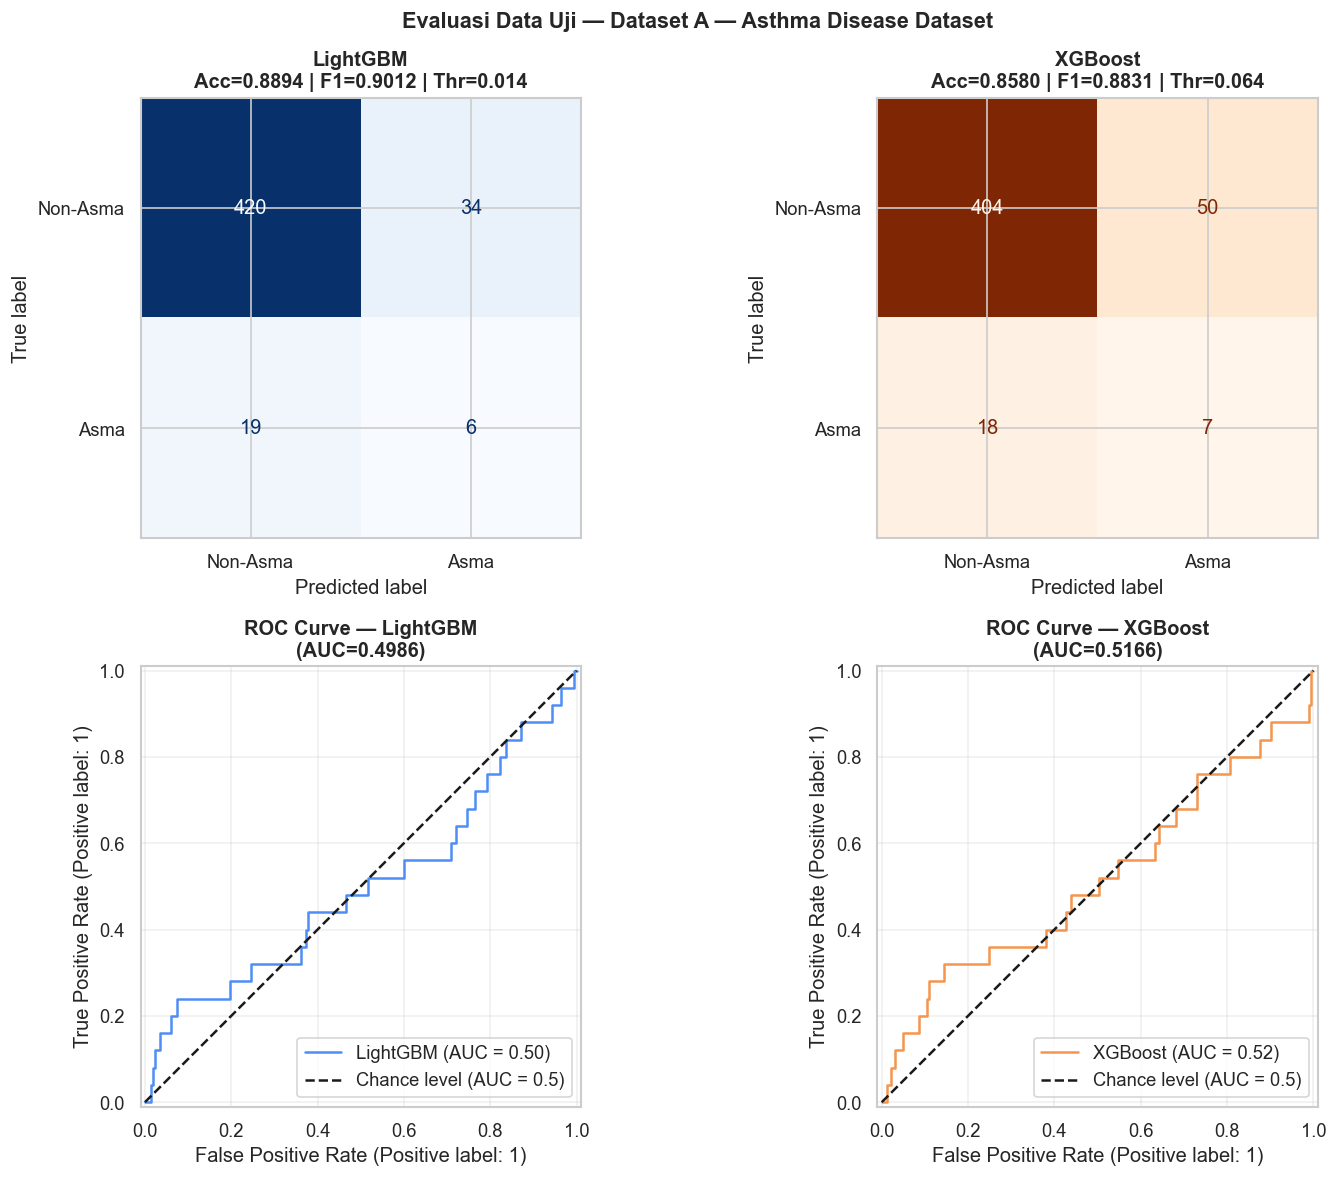

  ✅ Disimpan: 05_eval_datasetA.png


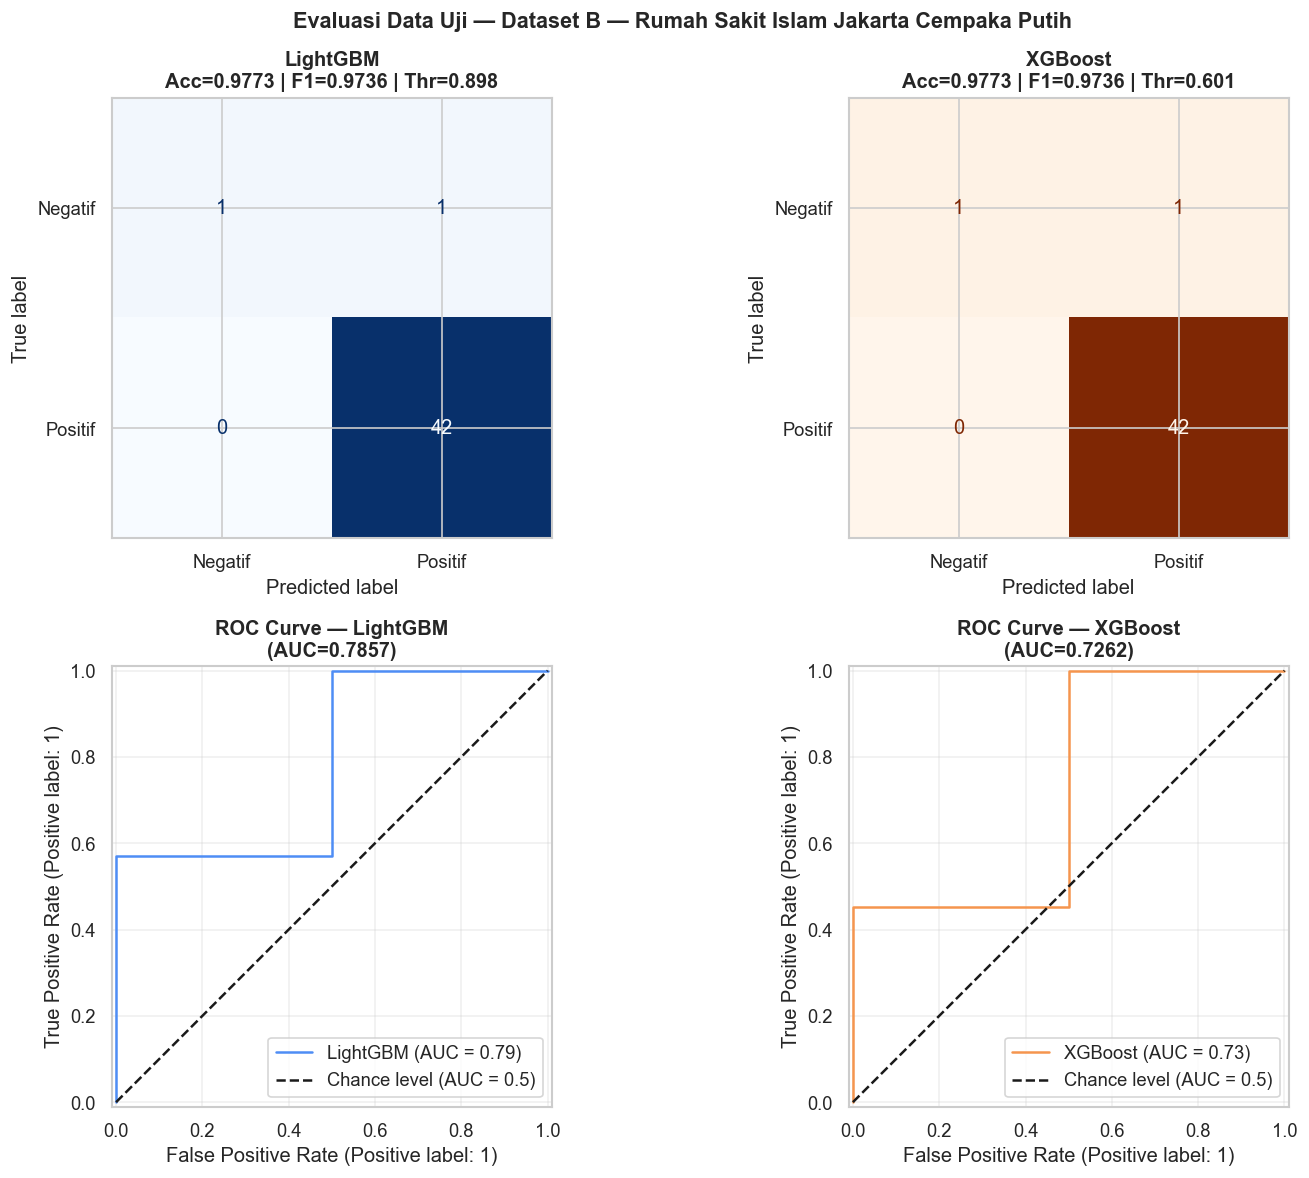

  ✅ Disimpan: 06_eval_datasetB.png


In [50]:
# Cell ini menampilkan Confusion Matrix dan ROC Curve untuk semua model pada data uji.
# Evaluasi ini dilakukan SEBELUM cross validation, mengikuti alur yang jelas dan terstruktur.

def plot_cm_roc(res_lgbm, res_xgb, y_test, dataset_name, labels_dict, filename):
    class_names = [labels_dict[k] for k in sorted(labels_dict)]
    fig, axes = plt.subplots(2, 2, figsize=(13, 10))
    fig.suptitle(f'Evaluasi Data Uji — {dataset_name}', fontsize=13, fontweight='bold')

    for ax, (name, res, cmap) in zip(
        [axes[0,0], axes[0,1]],
        [('LightGBM', res_lgbm, 'Blues'), ('XGBoost', res_xgb, 'Oranges')]
    ):
        disp = ConfusionMatrixDisplay(
            confusion_matrix=res['cm'], display_labels=class_names
        )
        disp.plot(ax=ax, colorbar=False, cmap=cmap)
        ax.set_title(
            f'{name}\nAcc={res["test_metrics"]["accuracy"]:.4f} | '
            f'F1={res["test_metrics"]["f1"]:.4f} | '
            f'Thr={res["threshold"]:.3f}',
            fontweight='bold'
        )

    for ax, (name, res, color) in zip(
        [axes[1,0], axes[1,1]],
        [('LightGBM', res_lgbm, '#4e8df5'), ('XGBoost', res_xgb, '#f5954e')]
    ):
        RocCurveDisplay.from_predictions(
            y_test, res['proba_test'], ax=ax,
            color=color, name=name, plot_chance_level=True
        )
        ax.set_title(f'ROC Curve — {name}\n(AUC={res["test_metrics"]["roc_auc"]:.4f})',
                     fontweight='bold')
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{MODEL_DIR}/{filename}', bbox_inches='tight', dpi=150)
    plt.show()
    print(f'  ✅ Disimpan: {filename}')


plot_cm_roc(res_lgbm_A, res_xgb_A, data_A['y_test'],
            'Dataset A — Asthma Disease Dataset', LABELS_A, '05_eval_datasetA.png')
plot_cm_roc(res_lgbm_B, res_xgb_B, data_B['y_test'],
            'Dataset B — Rumah Sakit Islam Jakarta Cempaka Putih', LABELS_B, '06_eval_datasetB.png')

## 7. Classification Report — Data Uji

In [51]:
# Cell ini menampilkan classification report lengkap per model per dataset pada data uji.

for res, ds, labels_d in [
    (res_lgbm_A, 'Dataset A', LABELS_A), (res_xgb_A, 'Dataset A', LABELS_A),
    (res_lgbm_B, 'Dataset B', LABELS_B), (res_xgb_B, 'Dataset B', LABELS_B),
]:
    y_te   = data_A['y_test'] if 'A' in ds else data_B['y_test']
    y_pred = (res['proba_test'] >= res['threshold']).astype(int)
    names  = [labels_d[k] for k in sorted(labels_d)]
    print(f"\n=== {res['model_name']} — {ds} ===")
    print(classification_report(y_te, y_pred, target_names=names))


=== LightGBM — Dataset A ===
              precision    recall  f1-score   support

    Non-Asma       0.96      0.93      0.94       454
        Asma       0.15      0.24      0.18        25

    accuracy                           0.89       479
   macro avg       0.55      0.58      0.56       479
weighted avg       0.91      0.89      0.90       479


=== XGBoost — Dataset A ===
              precision    recall  f1-score   support

    Non-Asma       0.96      0.89      0.92       454
        Asma       0.12      0.28      0.17        25

    accuracy                           0.86       479
   macro avg       0.54      0.58      0.55       479
weighted avg       0.91      0.86      0.88       479


=== LightGBM — Dataset B ===
              precision    recall  f1-score   support

     Negatif       1.00      0.50      0.67         2
     Positif       0.98      1.00      0.99        42

    accuracy                           0.98        44
   macro avg       0.99      0.75      

<!-- generated-table-cell:data-uji -->
### 7.1 Tabel Ringkasan Hasil Data Uji

Tabel berikut merangkum metrik evaluasi pada data uji untuk setiap kombinasi dataset dan model.


In [52]:
# generated-table-cell:data-uji
# Tabel ringkasan hasil evaluasi data uji

rows_test = []
for res, ds_label in [
    (res_lgbm_A, 'Dataset A'), (res_xgb_A, 'Dataset A'),
    (res_lgbm_B, 'Dataset B'), (res_xgb_B, 'Dataset B'),
]:
    tm = res['test_metrics']
    tt = res['timing_test']
    rows_test.append({
        'Dataset'        : ds_label,
        'Model'          : res['model_name'],
        'Akurasi'        : tm['accuracy'],
        'Presisi'        : tm['precision'],
        'Recall'         : tm['recall'],
        'F1-Score'       : tm['f1'],
        'AUC'            : tm['roc_auc'],
        'Threshold'      : res['threshold'],
        'Final Train (s)': tt['final_train_s'],
        'Test Pred (ms)' : tt['test_pred_s'] * 1000,
    })

df_hasil_data_uji = pd.DataFrame(rows_test)
metric_cols_test = ['Akurasi', 'Presisi', 'Recall', 'F1-Score', 'AUC', 'Threshold']
df_hasil_data_uji[metric_cols_test] = df_hasil_data_uji[metric_cols_test].round(4)
df_hasil_data_uji['Final Train (s)'] = df_hasil_data_uji['Final Train (s)'].round(3)
df_hasil_data_uji['Test Pred (ms)'] = df_hasil_data_uji['Test Pred (ms)'].round(2)

print('=' * 80)
print('  TABEL HASIL DATA UJI')
print('=' * 80)
print(df_hasil_data_uji.to_string(index=False))

df_hasil_data_uji.to_csv(f'{MODEL_DIR}/tabel_hasil_data_uji.csv', index=False, encoding='utf-8-sig')
print(f'OK Tabel disimpan: tabel_hasil_data_uji.csv')

df_hasil_data_uji.style     .set_caption('Tabel Hasil Data Uji')     .format({
        'Akurasi': '{:.4f}', 'Presisi': '{:.4f}', 'Recall': '{:.4f}',
        'F1-Score': '{:.4f}', 'AUC': '{:.4f}', 'Threshold': '{:.4f}',
        'Final Train (s)': '{:.3f}', 'Test Pred (ms)': '{:.2f}',
    })     .set_properties(**{'text-align': 'center', 'font-size': '12px'})     .highlight_max(subset=['Akurasi', 'Presisi', 'Recall', 'F1-Score', 'AUC'], color="#2d7137")


  TABEL HASIL DATA UJI
  Dataset    Model  Akurasi  Presisi  Recall  F1-Score    AUC  Threshold  Final Train (s)  Test Pred (ms)
Dataset A LightGBM   0.8894   0.9146  0.8894    0.9012 0.4986     0.0137            0.490            3.07
Dataset A  XGBoost   0.8580   0.9138  0.8580    0.8831 0.5166     0.0638            0.361            1.20
Dataset B LightGBM   0.9773   0.9778  0.9773    0.9736 0.7857     0.8979            0.050            0.62
Dataset B  XGBoost   0.9773   0.9778  0.9773    0.9736 0.7262     0.6007            0.139            0.55
OK Tabel disimpan: tabel_hasil_data_uji.csv


,Dataset,Model,Akurasi,Presisi,Recall,F1-Score,AUC,Threshold,Final Train (s),Test Pred (ms)
0,Dataset A,LightGBM,0.8894,0.9146,0.8894,0.9012,0.4986,0.0137,0.490,3.07
1,Dataset A,XGBoost,0.8580,0.9138,0.8580,0.8831,0.5166,0.0638,0.361,1.20
2,Dataset B,LightGBM,0.9773,0.9778,0.9773,0.9736,0.7857,0.8979,0.050,0.62
3,Dataset B,XGBoost,0.9773,0.9778,0.9773,0.9736,0.7262,0.6007,0.139,0.55


## 8. K-Fold Cross Validation — Dataset A (K=5)

Cross validation dilakukan **setelah** evaluasi data uji, menggunakan seluruh data training.
Dataset A menggunakan **K=5** karena memiliki 2.392 sampel sehingga setiap fold cukup representatif.

In [53]:
# Cell ini mendefinisikan fungsi cross validation yang berdiri sendiri (terpisah dari pelatihan final).
# Fungsi ini hanya melakukan CV — tidak melakukan pelatihan final ulang.

# Fungsi ini menjalankan validasi silang secara terpisah agar tidak tercampur dengan pelatihan final.
def run_cross_validation(X_res, y_res, k, model_name, dataset_name):
    """
    Stratified K-Fold Cross Validation — TERPISAH dari pelatihan final.
    ADASYN diterapkan di dalam setiap fold (hanya pada training fold — no leakage).

    Parameters
    ----------
    X_res, y_res : data training yang sudah di-resample ADASYN (level global)
    k            : jumlah fold
    model_name   : 'LightGBM' atau 'XGBoost'
    dataset_name : label dataset untuk print

    Return
    ------
    fold_results : list of dict (metrik per fold)
    cv_summary   : dict (mean ± std semua metrik)
    timing_cv    : dict (waktu komputasi CV)
    """
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)

    fold_results   = []
    cv_train_times = []
    cv_pred_times  = []

    print(f"\n{'─'*60}")
    print(f'  K-Fold CV — {model_name} | {dataset_name} | K={k}')
    print(f"{'─'*60}")

    t_cv_start = time.perf_counter()

    for fold_idx, (tr_idx, val_idx) in enumerate(skf.split(X_res, y_res), 1):
        X_tr_fold, X_val_fold = X_res[tr_idx], X_res[val_idx]
        y_tr_fold, y_val_fold = y_res[tr_idx], y_res[val_idx]

        # ADASYN di dalam fold — hanya training fold (no leakage)
        counts_fold = dict(zip(*np.unique(y_tr_fold, return_counts=True)))
        min_count   = min(counts_fold.values())
        n_nb_fold   = max(1, min(5, min_count - 1))
        try:
            ada = ADASYN(sampling_strategy='minority',
                         n_neighbors=n_nb_fold, random_state=RANDOM_STATE)
            X_tr_res, y_tr_res = ada.fit_resample(X_tr_fold, y_tr_fold)
        except Exception:
            X_tr_res, y_tr_res = X_tr_fold, y_tr_fold

        # Instansiasi model per fold
        lgbm_f, xgb_f = build_models(y_tr_res)
        model_fold = lgbm_f if 'LightGBM' in model_name else xgb_f

        # Training fold
        t0 = time.perf_counter()
        model_fold.fit(X_tr_res, y_tr_res)
        train_time = time.perf_counter() - t0
        cv_train_times.append(train_time)

        # Prediksi validasi fold
        t0 = time.perf_counter()
        proba_val = model_fold.predict_proba(X_val_fold)[:, 1]
        pred_time = time.perf_counter() - t0
        cv_pred_times.append(pred_time)

        # Threshold default 0.5 untuk konsistensi antar fold
        y_pred_val = (proba_val >= 0.5).astype(int)
        m = compute_metrics(y_val_fold, y_pred_val, proba_val)
        m.update({
            'fold'        : fold_idx,
            'train_time_s': round(train_time, 4),
            'pred_time_s' : round(pred_time, 6),
            'n_train'     : len(y_tr_res),
            'n_val'       : len(y_val_fold)
        })
        fold_results.append(m)
        print(f'  Fold {fold_idx}/{k} → Acc={m["accuracy"]:.4f} | Prec={m["precision"]:.4f} | '
              f'Recall={m["recall"]:.4f} | F1={m["f1"]:.4f} | '
              f'AUC={m["roc_auc"]:.4f} | Train={train_time:.2f}s')

    cv_total_time = time.perf_counter() - t_cv_start

    # Ringkasan CV
    metric_keys = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
    cv_summary = {}
    for mk in metric_keys:
        vals = [r[mk] for r in fold_results]
        cv_summary[f'cv_{mk}_mean'] = float(np.mean(vals))
        cv_summary[f'cv_{mk}_std']  = float(np.std(vals))

    print(f"\n  Ringkasan CV K={k} — {model_name} ({dataset_name})")
    print(f"  CV Mean Accuracy  : {cv_summary['cv_accuracy_mean']:.4f} ± {cv_summary['cv_accuracy_std']:.4f}")
    print(f"  CV Mean Precision : {cv_summary['cv_precision_mean']:.4f} ± {cv_summary['cv_precision_std']:.4f}")
    print(f"  CV Mean Recall    : {cv_summary['cv_recall_mean']:.4f} ± {cv_summary['cv_recall_std']:.4f}")
    print(f"  CV Mean F1-Score  : {cv_summary['cv_f1_mean']:.4f} ± {cv_summary['cv_f1_std']:.4f}")
    print(f"  CV Mean ROC-AUC   : {cv_summary['cv_roc_auc_mean']:.4f} ± {cv_summary['cv_roc_auc_std']:.4f}")

    timing_cv = {
        'cv_train_total_s'    : round(cv_total_time, 3),
        'cv_train_per_fold_s' : round(float(np.mean(cv_train_times)), 4),
        'cv_pred_per_fold_s'  : round(float(np.mean(cv_pred_times)), 6),
    }

    return fold_results, cv_summary, timing_cv


print('✅ Fungsi run_cross_validation siap.')

✅ Fungsi run_cross_validation siap.


In [54]:
# ── Jalankan K5-Fold CV — Dataset A (LightGBM) ──────────────────────────────
print('=' * 65)
print('  K=5 FOLD CROSS VALIDATION — DATASET A (Asma disease dataset)')
print('  Jumlah sampel: 2.392 | K=5 → ~478 sampel/fold')
print('=' * 65)

folds_lgbm_A, cv_lgbm_A, timing_cv_lgbm_A = run_cross_validation(
    X_A_res, y_A_res, K_FOLD_A, 'LightGBM', 'Dataset A'
)

folds_xgb_A, cv_xgb_A, timing_cv_xgb_A = run_cross_validation(
    X_A_res, y_A_res, K_FOLD_A, 'XGBoost', 'Dataset A'
)

# Gabungkan hasil CV ke dalam res dict yang sudah ada
res_lgbm_A['cv_summary']   = cv_lgbm_A
res_lgbm_A['fold_results'] = folds_lgbm_A
res_lgbm_A['k']            = K_FOLD_A
res_lgbm_A['timing']       = {**res_lgbm_A['timing_test'], **timing_cv_lgbm_A,
                               'total_s': round(timing_cv_lgbm_A['cv_train_total_s'] +
                                                res_lgbm_A['timing_test']['final_train_s'], 3)}

res_xgb_A['cv_summary']    = cv_xgb_A
res_xgb_A['fold_results']  = folds_xgb_A
res_xgb_A['k']             = K_FOLD_A
res_xgb_A['timing']        = {**res_xgb_A['timing_test'], **timing_cv_xgb_A,
                               'total_s': round(timing_cv_xgb_A['cv_train_total_s'] +
                                                res_xgb_A['timing_test']['final_train_s'], 3)}

print('\n✅ K5-Fold CV Dataset A selesai.')

  K=5 FOLD CROSS VALIDATION — DATASET A (Asma disease dataset)
  Jumlah sampel: 2.392 | K=5 → ~478 sampel/fold

────────────────────────────────────────────────────────────
  K-Fold CV — LightGBM | Dataset A | K=5
────────────────────────────────────────────────────────────
  Fold 1/5 → Acc=0.9684 | Prec=0.9703 | Recall=0.9684 | F1=0.9684 | AUC=0.9966 | Train=0.41s
  Fold 2/5 → Acc=0.9849 | Prec=0.9853 | Recall=0.9849 | F1=0.9849 | AUC=0.9988 | Train=0.38s
  Fold 3/5 → Acc=0.9766 | Prec=0.9777 | Recall=0.9766 | F1=0.9766 | AUC=0.9945 | Train=0.48s
  Fold 4/5 → Acc=0.9766 | Prec=0.9777 | Recall=0.9766 | F1=0.9766 | AUC=0.9972 | Train=0.40s
  Fold 5/5 → Acc=0.9766 | Prec=0.9777 | Recall=0.9766 | F1=0.9766 | AUC=0.9980 | Train=0.48s

  Ringkasan CV K=5 — LightGBM (Dataset A)
  CV Mean Accuracy  : 0.9766 ± 0.0052
  CV Mean Precision : 0.9777 ± 0.0048
  CV Mean Recall    : 0.9766 ± 0.0052
  CV Mean F1-Score  : 0.9766 ± 0.0052
  CV Mean ROC-AUC   : 0.9970 ± 0.0014

──────────────────────────

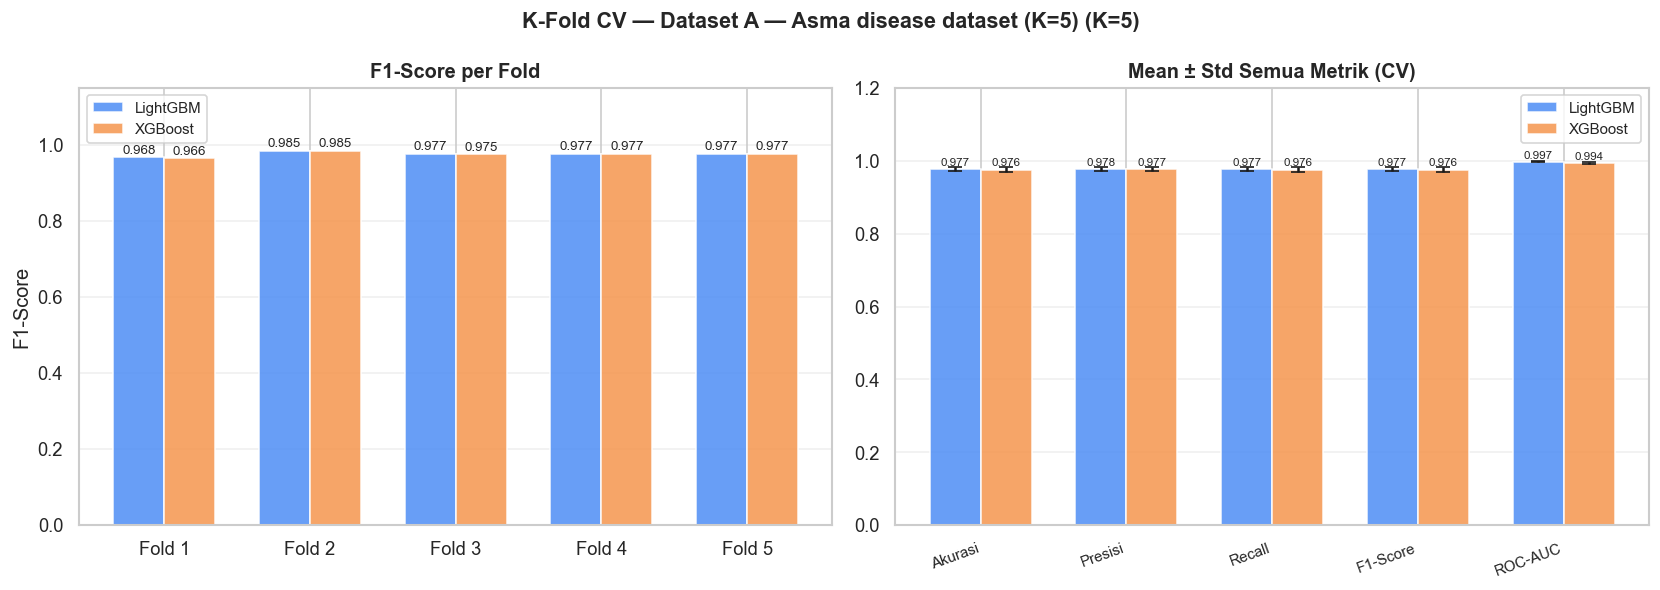

  ✅ Disimpan: 03_kfold_K5_datasetA.png


In [55]:
# Visualisasi hasil K5-Fold per fold dan ringkasan mean±std

def plot_fold_results(res_lgbm, res_xgb, dataset_title, k, filename):
    """Visualisasi F1-Score per fold dan mean±std semua metrik CV."""

    metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
    labels  = ['Akurasi', 'Presisi', 'Recall', 'F1-Score', 'ROC-AUC']
    w = 0.35

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'K-Fold CV — {dataset_title} (K={k})',
                 fontsize=13, fontweight='bold')

    # Kiri: F1-Score per fold
    ax = axes[0]
    folds_l = [r['f1'] for r in res_lgbm['fold_results']]
    folds_x = [r['f1'] for r in res_xgb['fold_results']]
    x = np.arange(k)
    ax.bar(x - w/2, folds_l, w, label='LightGBM', color='#4e8df5', alpha=0.85)
    ax.bar(x + w/2, folds_x, w, label='XGBoost',  color='#f5954e', alpha=0.85)
    for i, (vl, vx) in enumerate(zip(folds_l, folds_x)):
        ax.text(i - w/2, vl + 0.01, f'{vl:.3f}', ha='center', fontsize=8)
        ax.text(i + w/2, vx + 0.01, f'{vx:.3f}', ha='center', fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels([f'Fold {i+1}' for i in range(k)])
    ax.set_ylabel('F1-Score')
    ax.set_ylim(0, 1.15)
    ax.set_title('F1-Score per Fold', fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

    # Kanan: mean±std semua metrik
    ax2 = axes[1]
    xp = np.arange(len(metrics))
    lgbm_means = [res_lgbm['cv_summary'].get(f'cv_{m}_mean', 0) for m in metrics]
    xgb_means  = [res_xgb['cv_summary'].get(f'cv_{m}_mean',  0) for m in metrics]
    lgbm_stds  = [res_lgbm['cv_summary'].get(f'cv_{m}_std',  0) for m in metrics]
    xgb_stds   = [res_xgb['cv_summary'].get(f'cv_{m}_std',   0) for m in metrics]
    ax2.bar(xp - w/2, lgbm_means, w, yerr=lgbm_stds, label='LightGBM',
            color='#4e8df5', alpha=0.85, capsize=4)
    ax2.bar(xp + w/2, xgb_means,  w, yerr=xgb_stds,  label='XGBoost',
            color='#f5954e', alpha=0.85, capsize=4)
    ax2.set_xticks(xp)
    ax2.set_xticklabels(labels, rotation=20, ha='right', fontsize=9)
    ax2.set_ylim(0, 1.2)
    ax2.set_title('Mean ± Std Semua Metrik (CV)', fontweight='bold')
    ax2.legend(fontsize=9)
    ax2.grid(axis='y', alpha=0.3)
    for i, (vl, vx) in enumerate(zip(lgbm_means, xgb_means)):
        ax2.text(i - w/2, vl + 0.01, f'{vl:.3f}', ha='center', fontsize=7)
        ax2.text(i + w/2, vx + 0.01, f'{vx:.3f}', ha='center', fontsize=7)

    plt.tight_layout()
    plt.savefig(f'{MODEL_DIR}/{filename}', bbox_inches='tight', dpi=150)
    plt.show()
    print(f'  ✅ Disimpan: {filename}')


plot_fold_results(res_lgbm_A, res_xgb_A, 'Dataset A — Asma disease dataset (K=5)',
                  K_FOLD_A, '03_kfold_K5_datasetA.png')

In [56]:
# Tabel hasil per fold Dataset A — K=5

print('\n=== Tabel Hasil per Fold — Dataset A (K=5) ===')
for model_nm, folds in [('LightGBM', folds_lgbm_A), ('XGBoost', folds_xgb_A)]:
    df_f = pd.DataFrame(folds)[['fold','accuracy','precision','recall','f1','roc_auc','train_time_s']]
    df_f.columns = ['Fold','Akurasi','Presisi','Recall','F1-Score','AUC','Train(s)']
    print(f'\n  {model_nm}:')
    print(df_f.to_string(index=False))
    means = df_f[['Akurasi','Presisi','Recall','F1-Score','AUC']].mean()
    stds  = df_f[['Akurasi','Presisi','Recall','F1-Score','AUC']].std()
    print(f'  Mean  : {means.round(4).to_dict()}')
    print(f'  Std   : {stds.round(4).to_dict()}')


=== Tabel Hasil per Fold — Dataset A (K=5) ===

  LightGBM:
 Fold  Akurasi  Presisi   Recall  F1-Score      AUC  Train(s)
    1 0.968407 0.970289 0.968407  0.968378 0.996581    0.4107
    2 0.984869 0.985314 0.984869  0.984866 0.998819    0.3751
    3 0.976616 0.977662 0.976616  0.976604 0.994536    0.4779
    4 0.976616 0.977662 0.976616  0.976604 0.997185    0.3986
    5 0.976616 0.977665 0.976616  0.976606 0.997957    0.4763
  Mean  : {'Akurasi': 0.9766, 'Presisi': 0.9777, 'Recall': 0.9766, 'F1-Score': 0.9766, 'AUC': 0.997}
  Std   : {'Akurasi': 0.0058, 'Presisi': 0.0053, 'Recall': 0.0058, 'F1-Score': 0.0058, 'AUC': 0.0016}

  XGBoost:
 Fold  Akurasi  Presisi   Recall  F1-Score      AUC  Train(s)
    1 0.965659 0.967872 0.965659  0.965622 0.993539    0.3816
    2 0.984869 0.985314 0.984869  0.984866 0.995974    0.3617
    3 0.975241 0.976410 0.975241  0.975226 0.991077    0.4113
    4 0.976616 0.977662 0.976616  0.976604 0.994248    0.4273
    5 0.976616 0.977665 0.976616  0.976606

<!-- generated-table-cell:kfold-datasetA-table -->
### 8.1 Tabel Hasil Per Fold Dataset A

Tabel berikut menampilkan metrik validasi setiap fold untuk LightGBM dan XGBoost pada Dataset A.


In [57]:
# generated-table-cell:kfold-datasetA-table
# Tabel hasil per fold Dataset A (K=5) dalam bentuk DataFrame

def build_kfold_detail_table(dataset_label, k_fold, folds_lgbm, folds_xgb):
    rows = []
    for model_name, folds in [('LightGBM', folds_lgbm), ('XGBoost', folds_xgb)]:
        for fr in folds:
            rows.append({
                'Dataset'   : dataset_label,
                'Model'     : model_name,
                'K-Fold'    : k_fold,
                'Fold'      : fr['fold'],
                'Akurasi'   : fr['accuracy'],
                'Presisi'   : fr['precision'],
                'Recall'    : fr['recall'],
                'F1-Score'  : fr['f1'],
                'AUC'       : fr['roc_auc'],
                'Train (s)' : fr['train_time_s'],
                'Pred (ms)' : fr['pred_time_s'] * 1000,
                'N Train'   : fr['n_train'],
                'N Validasi': fr['n_val'],
            })
    df = pd.DataFrame(rows)
    for col in ['Akurasi', 'Presisi', 'Recall', 'F1-Score', 'AUC']:
        df[col] = df[col].round(4)
    df['Train (s)'] = df['Train (s)'].round(4)
    df['Pred (ms)'] = df['Pred (ms)'].round(3)
    return df

df_kfold_datasetA = build_kfold_detail_table('Dataset A', K_FOLD_A, folds_lgbm_A, folds_xgb_A)
print('=' * 90)
print('  TABEL HASIL PER FOLD DATASET A (K=5)')
print('=' * 90)
display(df_kfold_datasetA.style
        .set_caption('Tabel Hasil Per Fold Dataset A (K=5)')
        .format({
            'Akurasi': '{:.4f}', 'Presisi': '{:.4f}', 'Recall': '{:.4f}',
            'F1-Score': '{:.4f}', 'AUC': '{:.4f}',
            'Train (s)': '{:.4f}', 'Pred (ms)': '{:.3f}',
        })
        .set_properties(**{'text-align': 'center', 'font-size': '12px'}))

df_kfold_datasetA.to_csv(f'{MODEL_DIR}/tabel_hasil_per_fold_datasetA.csv', index=False, encoding='utf-8-sig')
print('OK Tabel disimpan: tabel_hasil_per_fold_datasetA.csv')


  TABEL HASIL PER FOLD DATASET A (K=5)


,Dataset,Model,K-Fold,Fold,Akurasi,Presisi,Recall,F1-Score,AUC,Train (s),Pred (ms),N Train,N Validasi
0,Dataset A,LightGBM,5,1,0.9684,0.9703,0.9684,0.9684,0.9966,0.4107,3.796,2908,728
1,Dataset A,LightGBM,5,2,0.9849,0.9853,0.9849,0.9849,0.9988,0.3751,3.830,2909,727
2,Dataset A,LightGBM,5,3,0.9766,0.9777,0.9766,0.9766,0.9945,0.4779,4.005,2909,727
3,Dataset A,LightGBM,5,4,0.9766,0.9777,0.9766,0.9766,0.9972,0.3986,4.867,2909,727
4,Dataset A,LightGBM,5,5,0.9766,0.9777,0.9766,0.9766,0.9980,0.4763,4.567,2909,727
5,Dataset A,XGBoost,5,1,0.9657,0.9679,0.9657,0.9656,0.9935,0.3816,2.257,2908,728
6,Dataset A,XGBoost,5,2,0.9849,0.9853,0.9849,0.9849,0.9960,0.3617,2.415,2909,727
7,Dataset A,XGBoost,5,3,0.9752,0.9764,0.9752,0.9752,0.9911,0.4113,2.142,2909,727
8,Dataset A,XGBoost,5,4,0.9766,0.9777,0.9766,0.9766,0.9942,0.4273,1.463,2909,727
9,Dataset A,XGBoost,5,5,0.9766,0.9777,0.9766,0.9766,0.9951,0.3448,2.250,2909,727


OK Tabel disimpan: tabel_hasil_per_fold_datasetA.csv


## 9. K-Fold Cross Validation — Dataset B (K=5)

Dataset B menggunakan **K=5** karena hanya memiliki ~12 sampel kelas minoritas.
Menggunakan K > 5 berisiko menghasilkan fold yang tidak memiliki sampel minoritas sama sekali,
sehingga K=5 adalah pilihan yang aman dan valid secara statistik untuk dataset ini.

In [58]:
# ── Jalankan K-Fold CV — Dataset B (Lokal/RS) ──────────────────────────────
print('=' * 65)
print(f'  K={K_FOLD_B} FOLD CROSS VALIDATION — DATASET B (Rumah Sakit Islam Jakarta Cempaka Putih)')
print('  Stratified K-Fold digunakan agar proporsi kelas Asma dan Tidak Asma tetap seimbang pada setiap fold.')
print('=' * 65)

folds_lgbm_B, cv_lgbm_B, timing_cv_lgbm_B = run_cross_validation(
    X_B_res, y_B_res, K_FOLD_B, 'LightGBM', 'Dataset B'
)

folds_xgb_B, cv_xgb_B, timing_cv_xgb_B = run_cross_validation(
    X_B_res, y_B_res, K_FOLD_B, 'XGBoost', 'Dataset B'
)

res_lgbm_B['cv_summary']   = cv_lgbm_B
res_lgbm_B['fold_results'] = folds_lgbm_B
res_lgbm_B['k']            = K_FOLD_B
res_lgbm_B['timing']       = {**res_lgbm_B['timing_test'], **timing_cv_lgbm_B,
                               'total_s': round(timing_cv_lgbm_B['cv_train_total_s'] +
                                                res_lgbm_B['timing_test']['final_train_s'], 3)}

res_xgb_B['cv_summary']    = cv_xgb_B
res_xgb_B['fold_results']  = folds_xgb_B
res_xgb_B['k']             = K_FOLD_B
res_xgb_B['timing']        = {**res_xgb_B['timing_test'], **timing_cv_xgb_B,
                               'total_s': round(timing_cv_xgb_B['cv_train_total_s'] +
                                                res_xgb_B['timing_test']['final_train_s'], 3)}

print(f'\n✅ K={K_FOLD_B} Fold CV Dataset B selesai.')

  K=5 FOLD CROSS VALIDATION — DATASET B (Rumah Sakit Islam Jakarta Cempaka Putih)
  Stratified K-Fold digunakan agar proporsi kelas Asma dan Tidak Asma tetap seimbang pada setiap fold.

────────────────────────────────────────────────────────────
  K-Fold CV — LightGBM | Dataset B | K=5
────────────────────────────────────────────────────────────
  Fold 1/5 → Acc=0.9394 | Prec=0.9394 | Recall=0.9394 | F1=0.9394 | AUC=0.9862 | Train=0.05s
  Fold 2/5 → Acc=0.9394 | Prec=0.9410 | Recall=0.9394 | F1=0.9393 | AUC=0.9835 | Train=0.05s
  Fold 3/5 → Acc=1.0000 | Prec=1.0000 | Recall=1.0000 | F1=1.0000 | AUC=1.0000 | Train=0.05s
  Fold 4/5 → Acc=0.9394 | Prec=0.9410 | Recall=0.9394 | F1=0.9393 | AUC=0.9972 | Train=0.04s
  Fold 5/5 → Acc=0.8939 | Prec=0.8943 | Recall=0.8939 | F1=0.8939 | AUC=0.9807 | Train=0.04s

  Ringkasan CV K=5 — LightGBM (Dataset B)
  CV Mean Accuracy  : 0.9424 ± 0.0337
  CV Mean Precision : 0.9431 ± 0.0336
  CV Mean Recall    : 0.9424 ± 0.0337
  CV Mean F1-Score  : 0.9424 

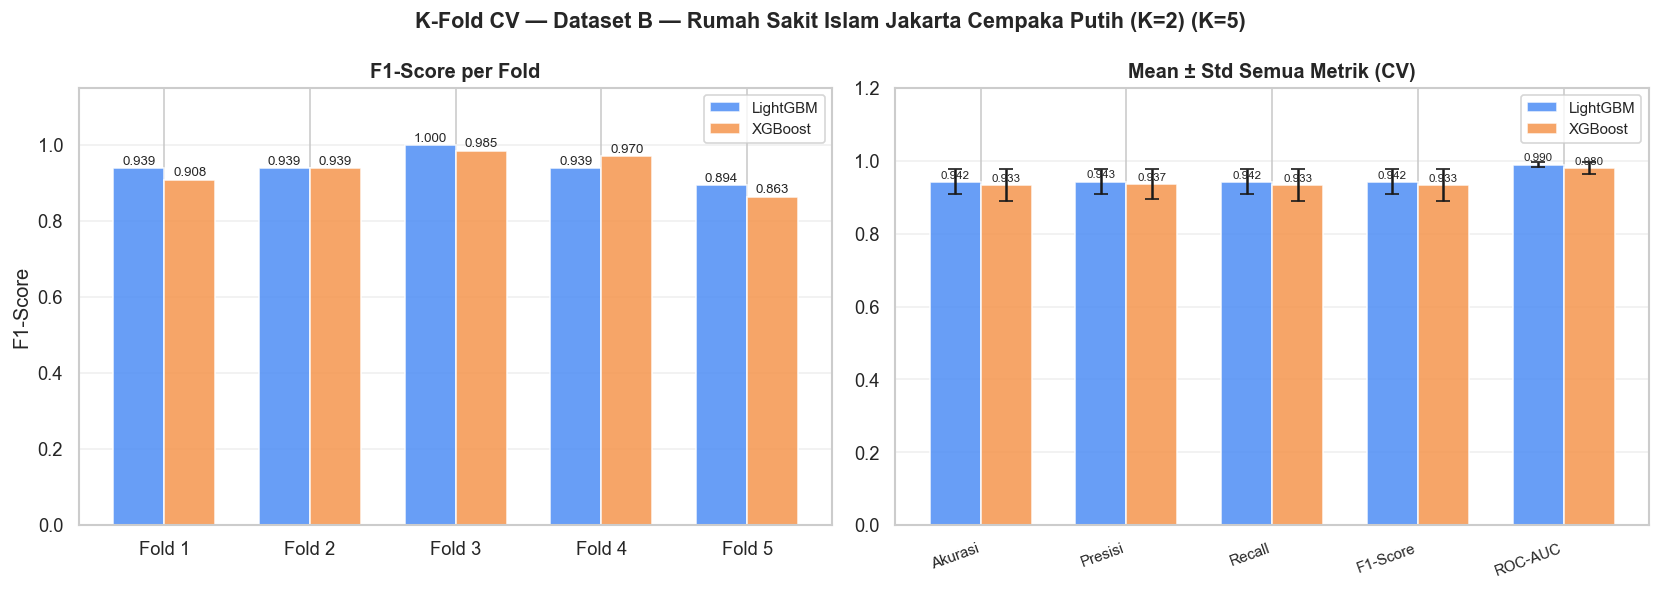

  ✅ Disimpan: 04_kfold_K2_datasetB.png


In [59]:
# Visualisasi K2-Fold CV — Dataset B
plot_fold_results(res_lgbm_B, res_xgb_B, 'Dataset B — Rumah Sakit Islam Jakarta Cempaka Putih (K=2)',
                  K_FOLD_B, '04_kfold_K2_datasetB.png')

In [60]:
# Tabel hasil per fold Dataset B — K=2

print('\n=== Tabel Hasil per Fold — Dataset B (K=5) ===')
for model_nm, folds in [('LightGBM', folds_lgbm_B), ('XGBoost', folds_xgb_B)]:
    df_f = pd.DataFrame(folds)[['fold','accuracy','precision','recall','f1','roc_auc','train_time_s']]
    df_f.columns = ['Fold','Akurasi','Presisi','Recall','F1-Score','AUC','Train(s)']
    print(f'\n  {model_nm}:')
    print(df_f.to_string(index=False))
    means = df_f[['Akurasi','Presisi','Recall','F1-Score','AUC']].mean()
    stds  = df_f[['Akurasi','Presisi','Recall','F1-Score','AUC']].std()
    print(f'  Mean  : {means.round(4).to_dict()}')
    print(f'  Std   : {stds.round(4).to_dict()}')


=== Tabel Hasil per Fold — Dataset B (K=5) ===

  LightGBM:
 Fold  Akurasi  Presisi   Recall  F1-Score      AUC  Train(s)
    1 0.939394 0.939394 0.939394  0.939394 0.986226    0.0547
    2 0.939394 0.941014 0.939394  0.939338 0.983471    0.0483
    3 1.000000 1.000000 1.000000  1.000000 1.000000    0.0495
    4 0.939394 0.941014 0.939394  0.939338 0.997245    0.0391
    5 0.893939 0.894301 0.893939  0.893915 0.980716    0.0383
  Mean  : {'Akurasi': 0.9424, 'Presisi': 0.9431, 'Recall': 0.9424, 'F1-Score': 0.9424, 'AUC': 0.9895}
  Std   : {'Akurasi': 0.0377, 'Presisi': 0.0376, 'Recall': 0.0377, 'F1-Score': 0.0377, 'AUC': 0.0086}

  XGBoost:
 Fold  Akurasi  Presisi   Recall  F1-Score      AUC  Train(s)
    1 0.909091 0.923077 0.909091  0.908333 0.958678    0.0935
    2 0.939394 0.939394 0.939394  0.939394 0.974288    0.0765
    3 0.984848 0.985294 0.984848  0.984845 1.000000    0.0761
    4 0.969697 0.969697 0.969697  0.969697 0.995409    0.0789
    5 0.863636 0.866667 0.863636  0.86335

<!-- generated-table-cell:kfold-datasetB-table -->
### 9.1 Tabel Hasil Per Fold Dataset B

Tabel berikut menampilkan metrik validasi setiap fold untuk LightGBM dan XGBoost pada Dataset B.


In [61]:
# generated-table-cell:kfold-datasetB-table
# Tabel hasil per fold Dataset B (K=2) dalam bentuk DataFrame

df_kfold_datasetB = build_kfold_detail_table('Dataset B', K_FOLD_B, folds_lgbm_B, folds_xgb_B)
print('=' * 90)
print('  TABEL HASIL PER FOLD DATASET B (K=2)')
print('=' * 90)
display(df_kfold_datasetB.style
        .set_caption('Tabel Hasil Per Fold Dataset B (K=2)')
        .format({
            'Akurasi': '{:.4f}', 'Presisi': '{:.4f}', 'Recall': '{:.4f}',
            'F1-Score': '{:.4f}', 'AUC': '{:.4f}',
            'Train (s)': '{:.4f}', 'Pred (ms)': '{:.3f}',
        })
        .set_properties(**{'text-align': 'center', 'font-size': '12px'}))

df_kfold_datasetB.to_csv(f'{MODEL_DIR}/tabel_hasil_per_fold_datasetB.csv', index=False, encoding='utf-8-sig')
print('OK Tabel disimpan: tabel_hasil_per_fold_datasetB.csv')


  TABEL HASIL PER FOLD DATASET B (K=2)


,Dataset,Model,K-Fold,Fold,Akurasi,Presisi,Recall,F1-Score,AUC,Train (s),Pred (ms),N Train,N Validasi
0,Dataset B,LightGBM,5,1,0.9394,0.9394,0.9394,0.9394,0.9862,0.0547,1.149,264,66
1,Dataset B,LightGBM,5,2,0.9394,0.9410,0.9394,0.9393,0.9835,0.0483,0.901,264,66
2,Dataset B,LightGBM,5,3,1.0000,1.0000,1.0000,1.0000,1.0000,0.0495,1.256,264,66
3,Dataset B,LightGBM,5,4,0.9394,0.9410,0.9394,0.9393,0.9972,0.0391,0.806,264,66
4,Dataset B,LightGBM,5,5,0.8939,0.8943,0.8939,0.8939,0.9807,0.0383,0.927,264,66
5,Dataset B,XGBoost,5,1,0.9091,0.9231,0.9091,0.9083,0.9587,0.0935,1.116,264,66
6,Dataset B,XGBoost,5,2,0.9394,0.9394,0.9394,0.9394,0.9743,0.0765,1.052,264,66
7,Dataset B,XGBoost,5,3,0.9848,0.9853,0.9848,0.9848,1.0000,0.0761,0.921,264,66
8,Dataset B,XGBoost,5,4,0.9697,0.9697,0.9697,0.9697,0.9954,0.0789,0.959,264,66
9,Dataset B,XGBoost,5,5,0.8636,0.8667,0.8636,0.8634,0.9725,0.0832,0.925,264,66


OK Tabel disimpan: tabel_hasil_per_fold_datasetB.csv


<!-- generated-table-cell:kfold-gabungan -->
### 9.1 Tabel Gabungan K-Fold Cross Validation

Tabel ini menggabungkan hasil validasi per fold dan ringkasan mean ± std untuk seluruh dataset dan model.


In [62]:
# generated-table-cell:kfold-gabungan
# Tabel gabungan K-Fold Cross Validation: detail per fold dan ringkasan mean ± std

cv_configs = [
    ('Dataset A', 'LightGBM', K_FOLD_A, folds_lgbm_A, cv_lgbm_A),
    ('Dataset A', 'XGBoost',  K_FOLD_A, folds_xgb_A,  cv_xgb_A),
    ('Dataset B', 'LightGBM', K_FOLD_B, folds_lgbm_B, cv_lgbm_B),
    ('Dataset B', 'XGBoost',  K_FOLD_B, folds_xgb_B,  cv_xgb_B),
]

rows_cv_detail = []

for ds_label, model_name, k_fold, fold_rows, _ in cv_configs:
    for fr in fold_rows:
        rows_cv_detail.append({
            'Dataset'   : ds_label,
            'Model'     : model_name,
            'K-Fold'    : k_fold,
            'Fold'      : fr['fold'],
            'Akurasi'   : fr['accuracy'],
            'Presisi'   : fr['precision'],
            'Recall'    : fr['recall'],
            'F1-Score'  : fr['f1'],
            'AUC'       : fr['roc_auc'],
            'Train (s)' : fr['train_time_s'],
            'Pred (ms)' : fr['pred_time_s'] * 1000,
            'N Train'   : fr['n_train'],
            'N Validasi': fr['n_val'],
        })

df_kfold_detail_raw = pd.DataFrame(rows_cv_detail)

# Tabel detail untuk ditampilkan
df_kfold_detail = df_kfold_detail_raw.copy()

for col in ['Akurasi', 'Presisi', 'Recall', 'F1-Score', 'AUC']:
    df_kfold_detail[col] = df_kfold_detail[col].round(4)

df_kfold_detail['Train (s)'] = df_kfold_detail['Train (s)'].round(4)
df_kfold_detail['Pred (ms)'] = df_kfold_detail['Pred (ms)'].round(3)

# Ringkasan mean ± std dihitung dari data mentah, bukan data yang sudah dibulatkan
summary_cols = ['Akurasi', 'Presisi', 'Recall', 'F1-Score', 'AUC', 'Train (s)', 'Pred (ms)']

df_summary_num = (
    df_kfold_detail_raw
    .groupby(['Dataset', 'Model', 'K-Fold'])[summary_cols]
    .agg(['mean', 'std'])
    .reset_index()
)

rows_cv_summary = []

for _, row in df_summary_num.iterrows():
    summary_row = {
        'Dataset': row[('Dataset', '')],
        'Model': row[('Model', '')],
        'K-Fold': int(row[('K-Fold', '')]),
    }

    for col in summary_cols:
        mean_val = row[(col, 'mean')]
        std_val = row[(col, 'std')]

        if pd.isna(std_val):
            std_val = 0.0

        summary_row[col] = f"{mean_val:.4f} ± {std_val:.4f}"

    rows_cv_summary.append(summary_row)

df_kfold_summary = pd.DataFrame(rows_cv_summary)

print('=' * 90)
print('  TABEL DETAIL K-FOLD CROSS VALIDATION')
print('=' * 90)
print(df_kfold_detail.to_string(index=False))

print('\n' + '=' * 90)
print('  TABEL RINGKASAN K-FOLD CROSS VALIDATION (MEAN ± STD)')
print('=' * 90)
print(df_kfold_summary.to_string(index=False))

df_kfold_detail.to_csv(f'{MODEL_DIR}/tabel_kfold_cross_validation_detail.csv', index=False, encoding='utf-8-sig')
df_kfold_summary.to_csv(f'{MODEL_DIR}/tabel_kfold_cross_validation_summary.csv', index=False, encoding='utf-8-sig')

print('\n  OK Tabel disimpan: tabel_kfold_cross_validation_detail.csv')
print('  OK Tabel disimpan: tabel_kfold_cross_validation_summary.csv')

df_kfold_summary.style \
    .set_caption('Ringkasan K-Fold Cross Validation (Mean ± Std)') \
    .set_properties(**{'text-align': 'center', 'font-size': '12px'})

  TABEL DETAIL K-FOLD CROSS VALIDATION
  Dataset    Model  K-Fold  Fold  Akurasi  Presisi  Recall  F1-Score    AUC  Train (s)  Pred (ms)  N Train  N Validasi
Dataset A LightGBM       5     1   0.9684   0.9703  0.9684    0.9684 0.9966     0.4107      3.796     2908         728
Dataset A LightGBM       5     2   0.9849   0.9853  0.9849    0.9849 0.9988     0.3751      3.830     2909         727
Dataset A LightGBM       5     3   0.9766   0.9777  0.9766    0.9766 0.9945     0.4779      4.005     2909         727
Dataset A LightGBM       5     4   0.9766   0.9777  0.9766    0.9766 0.9972     0.3986      4.867     2909         727
Dataset A LightGBM       5     5   0.9766   0.9777  0.9766    0.9766 0.9980     0.4763      4.567     2909         727
Dataset A  XGBoost       5     1   0.9657   0.9679  0.9657    0.9656 0.9935     0.3816      2.257     2908         728
Dataset A  XGBoost       5     2   0.9849   0.9853  0.9849    0.9849 0.9960     0.3617      2.415     2909         727
Dataset A

,Dataset,Model,K-Fold,Akurasi,Presisi,Recall,F1-Score,AUC,Train (s),Pred (ms)
0,Dataset A,LightGBM,5,0.9766 ± 0.0058,0.9777 ± 0.0053,0.9766 ± 0.0058,0.9766 ± 0.0058,0.9970 ± 0.0016,0.4277 ± 0.0469,4.2130 ± 0.4788
1,Dataset A,XGBoost,5,0.9758 ± 0.0068,0.9770 ± 0.0062,0.9758 ± 0.0068,0.9758 ± 0.0068,0.9940 ± 0.0019,0.3853 ± 0.0341,2.1054 ± 0.3721
2,Dataset B,LightGBM,5,0.9424 ± 0.0377,0.9431 ± 0.0376,0.9424 ± 0.0377,0.9424 ± 0.0377,0.9895 ± 0.0086,0.0460 ± 0.0071,1.0078 ± 0.1872
3,Dataset B,XGBoost,5,0.9333 ± 0.0486,0.9368 ± 0.0462,0.9333 ± 0.0486,0.9331 ± 0.0488,0.9802 ± 0.0172,0.0816 ± 0.0072,0.9946 ± 0.0860


## 9.2 Tambahan Revisi — Ringkasan K-Fold Mean ± Std dengan Waktu Komputasi

Bagian ini ditambahkan untuk melengkapi ringkasan hasil K-Fold Cross Validation agar mencakup rata-rata dan standar deviasi dari akurasi, presisi, recall, F1-score, AUC, serta waktu komputasi pelatihan pada setiap fold.

In [63]:
# Tambahan revisi: ringkasan K-Fold Cross Validation Mean ± Std termasuk waktu komputasi
# Cell ini tidak mengubah hasil CV yang sudah ada, hanya merangkum ulang dari df_kfold_detail.

metric_cols_revisi = ['Akurasi', 'Presisi', 'Recall', 'F1-Score', 'AUC', 'Train (s)']

rows_summary_revisi = []
for (dataset_name, model_name, k_fold), group in df_kfold_detail.groupby(['Dataset', 'Model', 'K-Fold']):
    row = {
        'Dataset': dataset_name,
        'Model': model_name,
        'K-Fold': int(k_fold)
    }
    for col in metric_cols_revisi:
        mean_val = group[col].mean()
        std_val = group[col].std(ddof=0)
        if col == 'Train (s)':
            row['Waktu Komputasi (s)'] = f'{mean_val:.4f} ± {std_val:.4f}'
        else:
            row[col] = f'{mean_val:.4f} ± {std_val:.4f}'
    rows_summary_revisi.append(row)

df_kfold_summary_revisi = pd.DataFrame(rows_summary_revisi)

# Urutan kolom untuk laporan
df_kfold_summary_revisi = df_kfold_summary_revisi[
    ['Dataset', 'Model', 'K-Fold', 'Akurasi', 'Presisi', 'Recall', 'F1-Score', 'AUC', 'Waktu Komputasi (s)']
]

print('=' * 100)
print('  RINGKASAN K-FOLD CROSS VALIDATION (MEAN ± STD) + WAKTU KOMPUTASI')
print('=' * 100)
print(df_kfold_summary_revisi.to_string(index=False))

df_kfold_summary_revisi.to_csv(f'{MODEL_DIR}/tabel_kfold_summary_mean_std_waktu.csv',
                               index=False, encoding='utf-8-sig')
print('\n  OK Tabel disimpan: tabel_kfold_summary_mean_std_waktu.csv')

df_kfold_summary_revisi.style \
    .set_caption('Ringkasan K-Fold Cross Validation (Mean ± Std) dengan Waktu Komputasi') \
    .set_properties(**{'text-align': 'center', 'font-size': '12px'})

  RINGKASAN K-FOLD CROSS VALIDATION (MEAN ± STD) + WAKTU KOMPUTASI
  Dataset    Model  K-Fold         Akurasi         Presisi          Recall        F1-Score             AUC Waktu Komputasi (s)
Dataset A LightGBM       5 0.9766 ± 0.0052 0.9777 ± 0.0047 0.9766 ± 0.0052 0.9766 ± 0.0052 0.9970 ± 0.0015     0.4277 ± 0.0419
Dataset A  XGBoost       5 0.9758 ± 0.0061 0.9770 ± 0.0055 0.9758 ± 0.0061 0.9758 ± 0.0061 0.9940 ± 0.0017     0.3853 ± 0.0305
Dataset B LightGBM       5 0.9424 ± 0.0338 0.9431 ± 0.0336 0.9424 ± 0.0338 0.9424 ± 0.0338 0.9895 ± 0.0077     0.0460 ± 0.0063
Dataset B  XGBoost       5 0.9333 ± 0.0435 0.9368 ± 0.0413 0.9333 ± 0.0435 0.9331 ± 0.0436 0.9802 ± 0.0154     0.0816 ± 0.0064

  OK Tabel disimpan: tabel_kfold_summary_mean_std_waktu.csv


,Dataset,Model,K-Fold,Akurasi,Presisi,Recall,F1-Score,AUC,Waktu Komputasi (s)
0,Dataset A,LightGBM,5,0.9766 ± 0.0052,0.9777 ± 0.0047,0.9766 ± 0.0052,0.9766 ± 0.0052,0.9970 ± 0.0015,0.4277 ± 0.0419
1,Dataset A,XGBoost,5,0.9758 ± 0.0061,0.9770 ± 0.0055,0.9758 ± 0.0061,0.9758 ± 0.0061,0.9940 ± 0.0017,0.3853 ± 0.0305
2,Dataset B,LightGBM,5,0.9424 ± 0.0338,0.9431 ± 0.0336,0.9424 ± 0.0338,0.9424 ± 0.0338,0.9895 ± 0.0077,0.0460 ± 0.0063
3,Dataset B,XGBoost,5,0.9333 ± 0.0435,0.9368 ± 0.0413,0.9333 ± 0.0435,0.9331 ± 0.0436,0.9802 ± 0.0154,0.0816 ± 0.0064


## 9.3 Tambahan Revisi — Boxplot Perbandingan LightGBM dan XGBoost

Bagian ini menampilkan boxplot perbandingan hasil K-Fold Cross Validation antara LightGBM dan XGBoost. Boxplot digunakan untuk melihat sebaran nilai evaluasi pada setiap fold sehingga kestabilan performa kedua algoritma dapat dibandingkan secara visual.

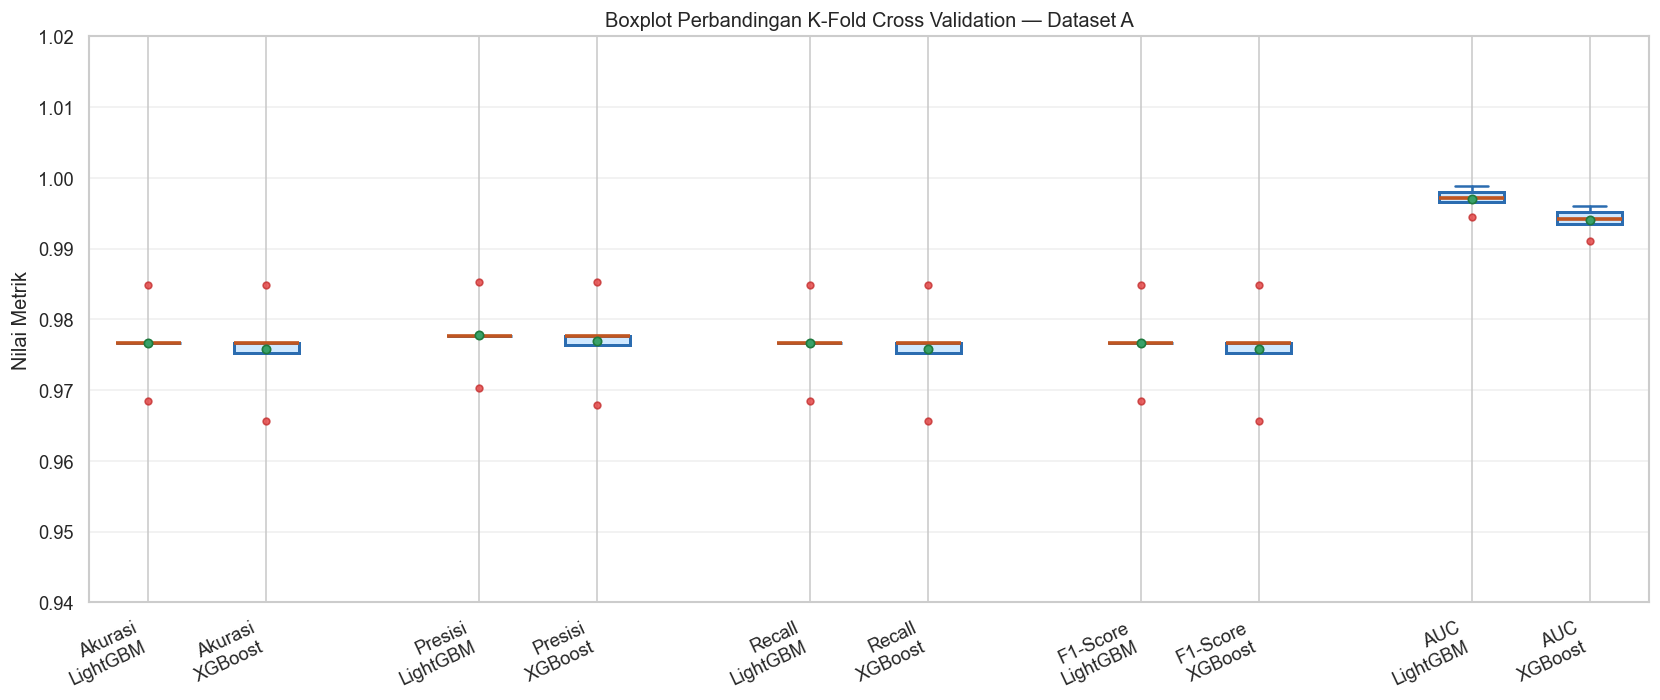

  OK Boxplot disimpan: boxplot_kfold_dataset_a.png


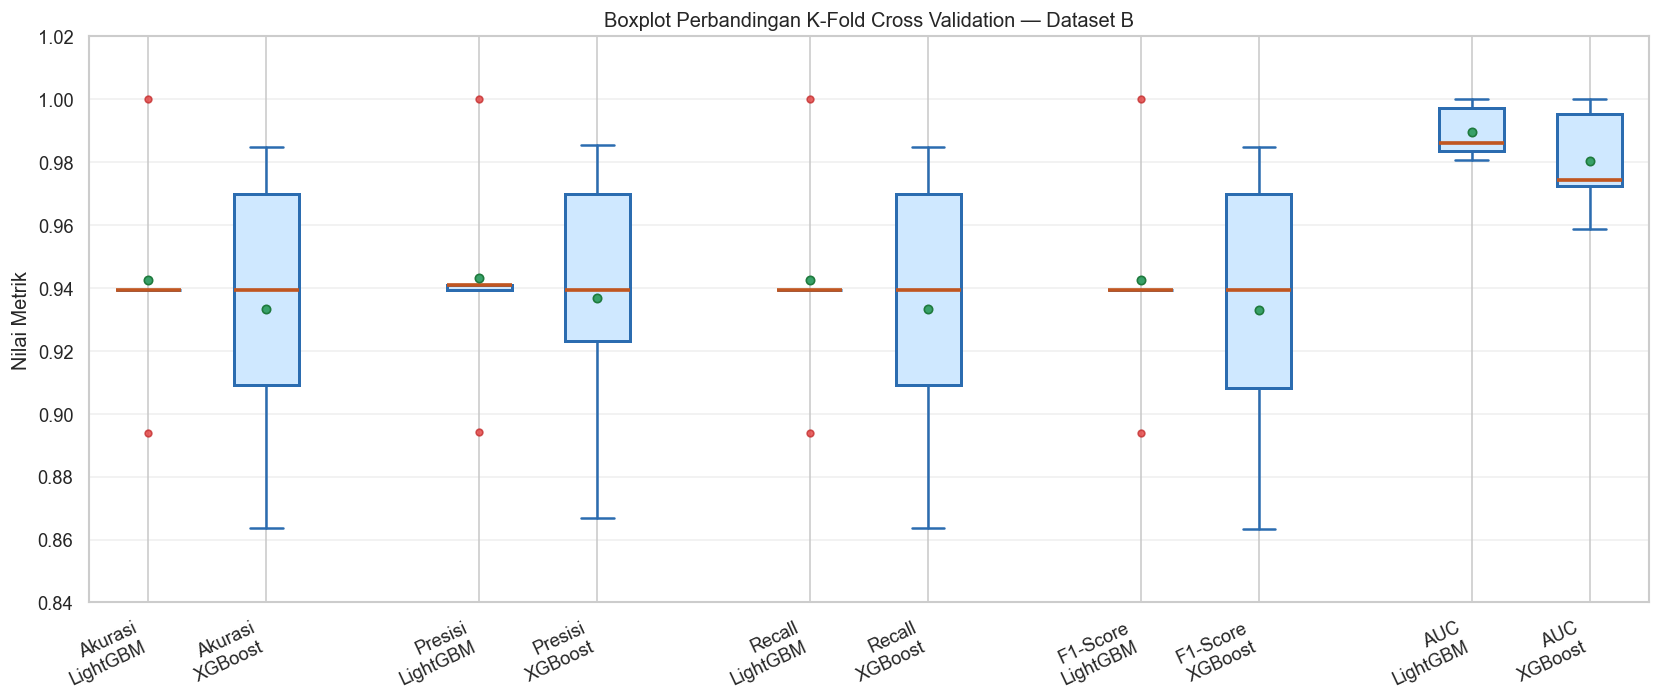

  OK Boxplot disimpan: boxplot_kfold_dataset_b.png


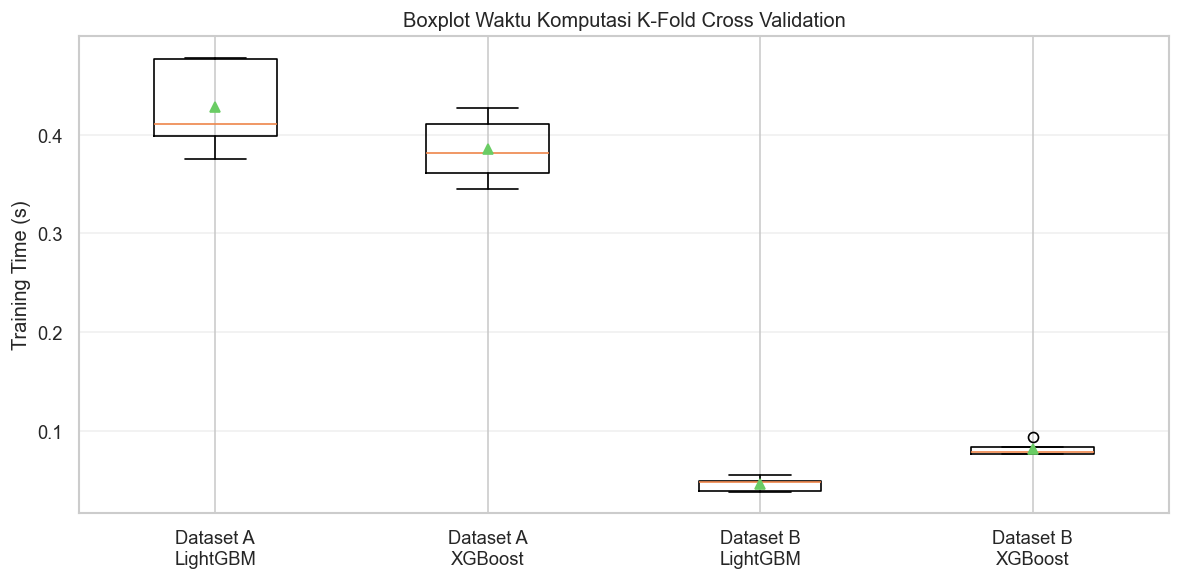

  OK Boxplot waktu komputasi disimpan: boxplot_kfold_waktu_komputasi.png


In [64]:
# Tambahan revisi: boxplot perbandingan LightGBM dan XGBoost berdasarkan hasil K-Fold CV
# Cell ini hanya membuat visualisasi dari df_kfold_detail, tidak mengubah hasil training/model.

def buat_boxplot_kfold_per_dataset(df_detail, dataset_name):
    """Membuat boxplot metrik evaluasi K-Fold untuk LightGBM dan XGBoost pada satu dataset."""
    metrics = ['Akurasi', 'Presisi', 'Recall', 'F1-Score', 'AUC']
    models = ['LightGBM', 'XGBoost']

    data_box = []
    posisi = []
    label_posisi = []
    pos = 1

    for metric in metrics:
        for model in models:
            nilai = df_detail[
                (df_detail['Dataset'] == dataset_name) &
                (df_detail['Model'] == model)
            ][metric].values
            data_box.append(nilai)
            posisi.append(pos)
            label_posisi.append(f'{metric}\n{model}')
            pos += 1
        pos += 0.8

    plt.figure(figsize=(14, 6))
    boxprops = dict(facecolor='#cfe8ff', edgecolor='#2b6cb0', linewidth=1.8)
    whiskerprops = dict(color='#2b6cb0', linewidth=1.5)
    capprops = dict(color='#2b6cb0', linewidth=1.5)
    medianprops = dict(color='#c05621', linewidth=2.2)
    meanprops = dict(marker='o', markerfacecolor='#38a169', markeredgecolor='#1f7a3d', markersize=5)
    flierprops = dict(marker='o', markerfacecolor='#e53e3e', markeredgecolor='#c53030', markersize=4, alpha=0.8)

    plt.boxplot(
        data_box,
        positions=posisi,
        widths=0.55,
        showmeans=True,
        patch_artist=True,
        boxprops=boxprops,
        whiskerprops=whiskerprops,
        capprops=capprops,
        medianprops=medianprops,
        meanprops=meanprops,
        flierprops=flierprops
    )
    semua_nilai = np.concatenate(data_box)
    y_min = max(0.0, np.floor((semua_nilai.min() - 0.02) * 100) / 100)
    y_max = min(1.02, np.ceil((semua_nilai.max() + 0.01) * 100) / 100)
    tick_step = 0.01 if (y_max - y_min) <= 0.15 else 0.02
    y_ticks = np.arange(y_min, y_max + tick_step, tick_step)

    plt.xticks(posisi, label_posisi, rotation=25, ha='right')
    plt.ylim(y_min, y_max)
    plt.yticks(y_ticks, [f'{y:.2f}' for y in y_ticks])
    plt.ylabel('Nilai Metrik')
    plt.title(f'Boxplot Perbandingan K-Fold Cross Validation — {dataset_name}')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()

    filename = f'boxplot_kfold_{dataset_name.lower().replace(" ", "_")}.png'
    plt.savefig(f'{MODEL_DIR}/{filename}', bbox_inches='tight', dpi=150)
    plt.show()
    print(f'  OK Boxplot disimpan: {filename}')

def buat_boxplot_waktu_komputasi(df_detail):
    """Membuat boxplot waktu komputasi training per fold untuk semua dataset dan model."""
    kategori = []
    data_box = []

    for dataset_name in df_detail['Dataset'].unique():
        for model in ['LightGBM', 'XGBoost']:
            nilai = df_detail[
                (df_detail['Dataset'] == dataset_name) &
                (df_detail['Model'] == model)
            ]['Train (s)'].values
            kategori.append(f'{dataset_name}\n{model}')
            data_box.append(nilai)

    plt.figure(figsize=(10, 5))
    plt.boxplot(data_box, labels=kategori, showmeans=True)
    plt.ylabel('Training Time (s)')
    plt.title('Boxplot Waktu Komputasi K-Fold Cross Validation')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()

    filename = 'boxplot_kfold_waktu_komputasi.png'
    plt.savefig(f'{MODEL_DIR}/{filename}', bbox_inches='tight', dpi=150)
    plt.show()
    print(f'  OK Boxplot waktu komputasi disimpan: {filename}')

buat_boxplot_kfold_per_dataset(df_kfold_detail, 'Dataset A')
buat_boxplot_kfold_per_dataset(df_kfold_detail, 'Dataset B')
buat_boxplot_waktu_komputasi(df_kfold_detail)

## 10. Tabel Ringkasan Waktu Komputasi

In [65]:
print('=' * 70)


## 11. Feature Importance

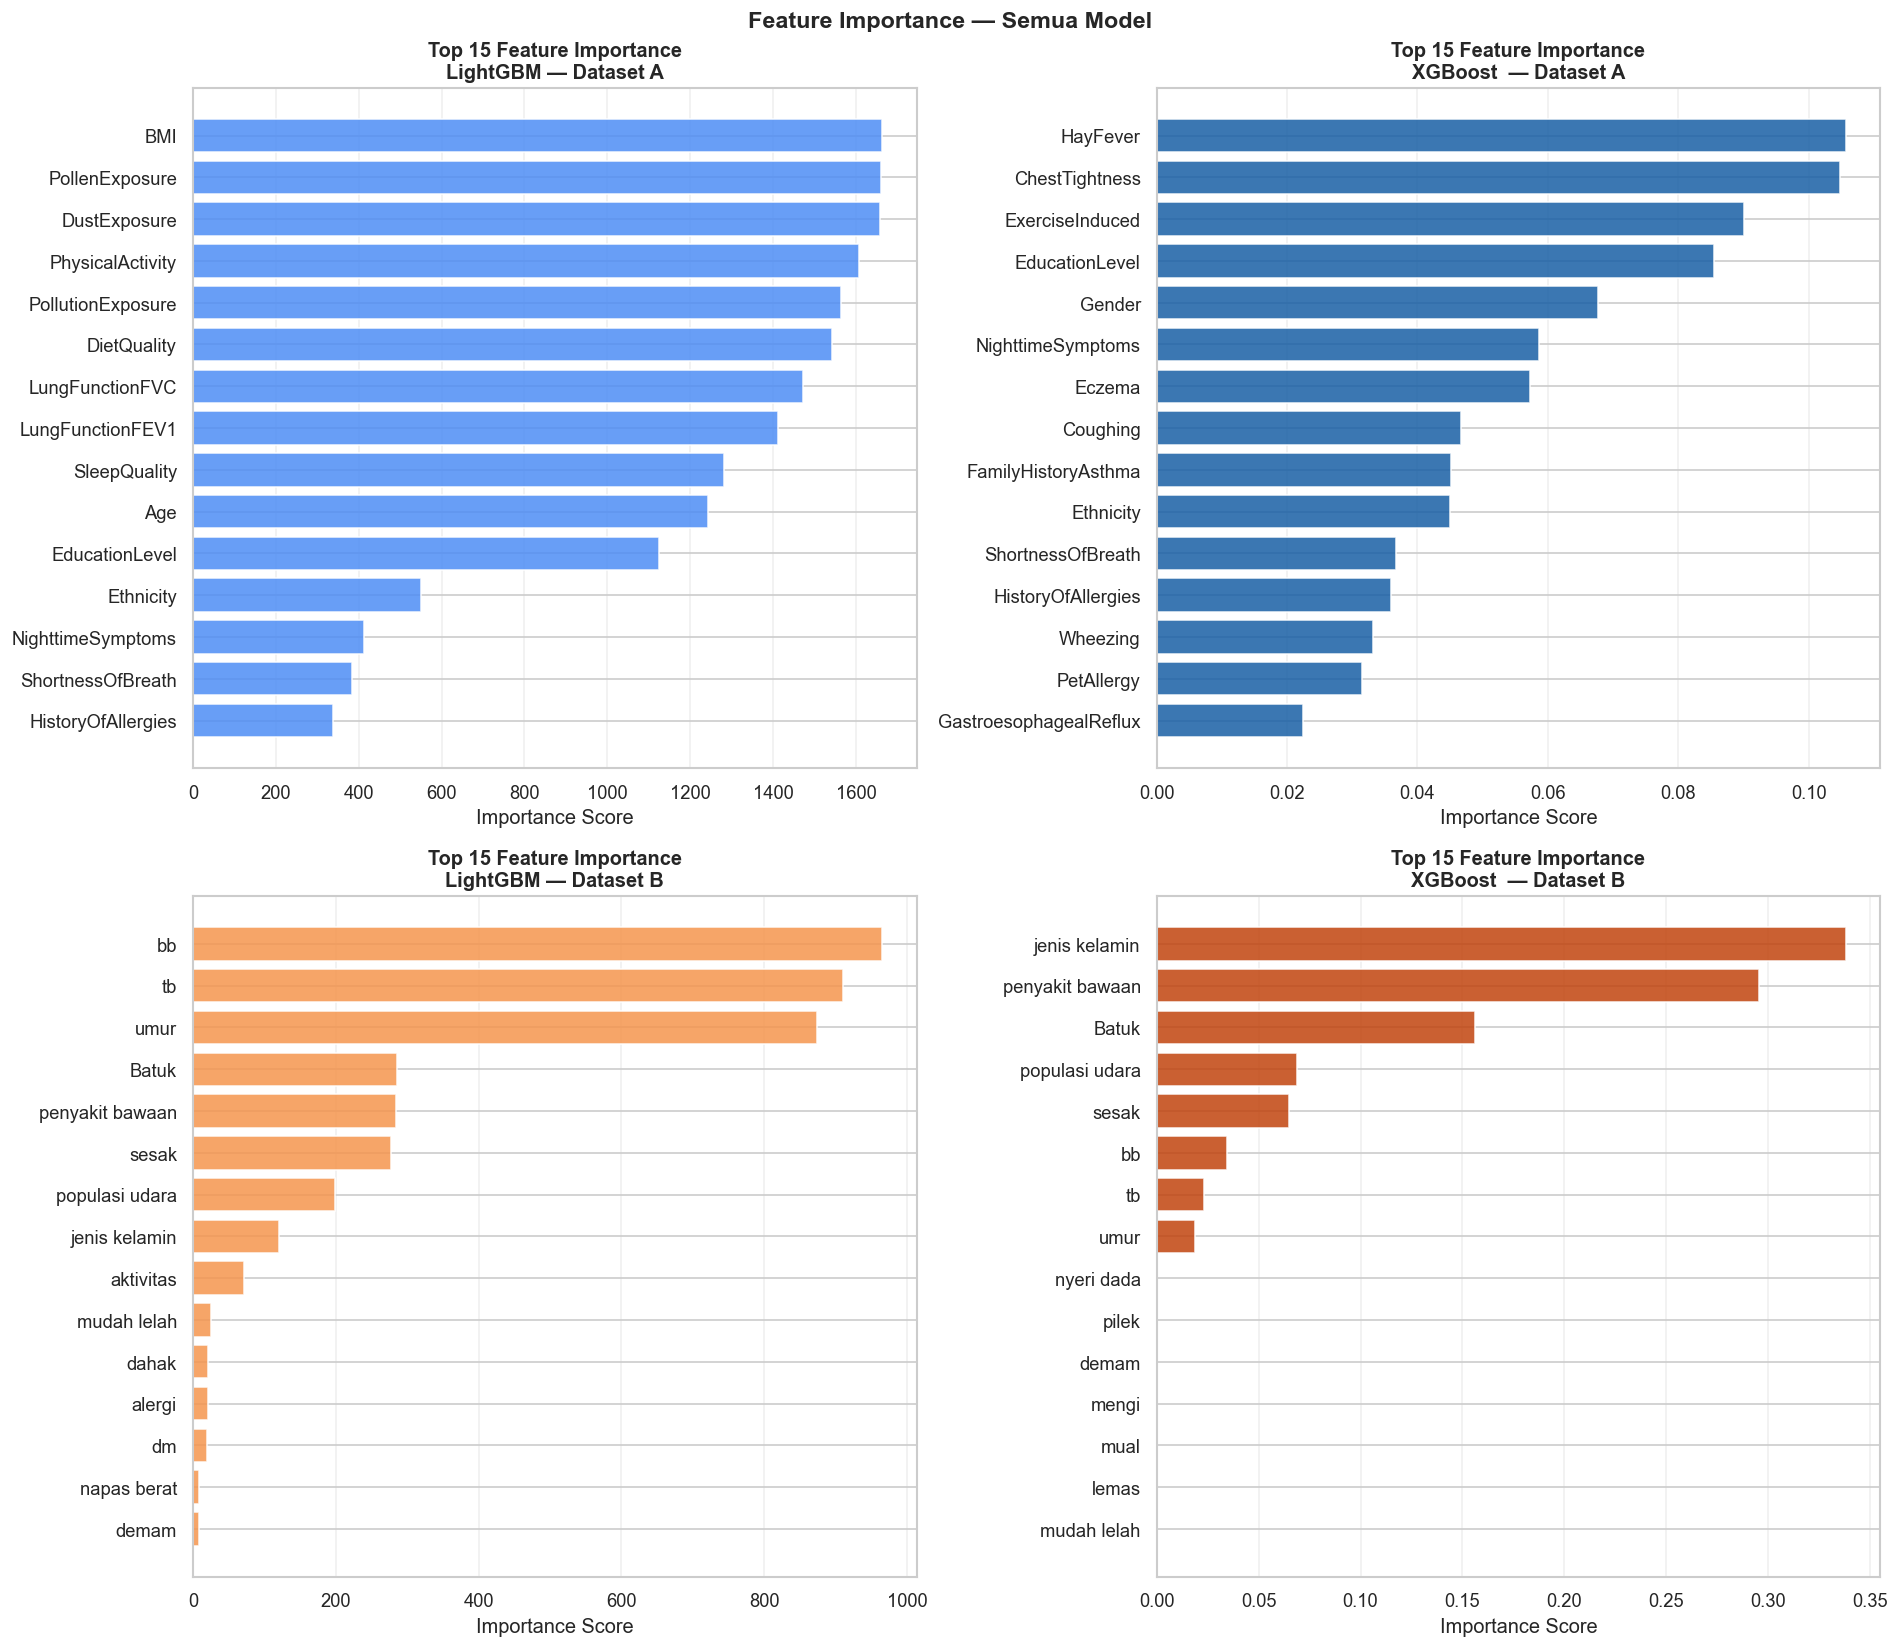

  ✅ Disimpan: 08_feature_importance.png


In [66]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
configs = [
    (res_lgbm_A['model'], FEATURES_A, 'LightGBM — Dataset A', axes[0,0], '#4e8df5'),
    (res_xgb_A['model'],  FEATURES_A, 'XGBoost  — Dataset A', axes[0,1], '#185FA5'),
    (res_lgbm_B['model'], FEATURES_B, 'LightGBM — Dataset B', axes[1,0], '#f5954e'),
    (res_xgb_B['model'],  FEATURES_B, 'XGBoost  — Dataset B', axes[1,1], '#c1440e'),
]
for model, feats, title, ax, color in configs:
    imp = model.feature_importances_
    idx = np.argsort(imp)[-15:]
    ax.barh([feats[i] for i in idx], imp[idx], color=color, alpha=0.85)
    ax.set_title(f'Top 15 Feature Importance\n{title}', fontweight='bold')
    ax.set_xlabel('Importance Score')
    ax.grid(axis='x', alpha=0.3)
plt.suptitle('Feature Importance — Semua Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/08_feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()
print('  ✅ Disimpan: 08_feature_importance.png')

## 12. Tabel Perbandingan Final — CV + Data Uji

In [67]:
print('=' * 80)
print('  TABEL PERBANDINGAN FINAL — CV + DATA UJI + WAKTU KOMPUTASI')
print('  Metrik Utama: Macro F1-Score')
print('=' * 80)

all_rows = []
for res, ds_label in [
    (res_lgbm_A, 'Dataset A'), (res_xgb_A, 'Dataset A'),
    (res_lgbm_B, 'Dataset B'), (res_xgb_B, 'Dataset B'),
]:
    s  = res['cv_summary']
    tm = res['test_metrics']
    t  = res['timing']
    all_rows.append({
        'Dataset'            : ds_label,
        'Model'              : res['model_name'],
        'K-Fold'             : res['k'],
        'CV Akurasi'         : f"{s['cv_accuracy_mean']:.4f} ±{s['cv_accuracy_std']:.4f}",
        'CV Presisi'         : f"{s['cv_precision_mean']:.4f} ±{s['cv_precision_std']:.4f}",
        'CV Recall'          : f"{s['cv_recall_mean']:.4f} ±{s['cv_recall_std']:.4f}",
        'CV F1-Score'        : f"{s['cv_f1_mean']:.4f} ±{s['cv_f1_std']:.4f}",
        'CV AUC'             : f"{s['cv_roc_auc_mean']:.4f} ±{s['cv_roc_auc_std']:.4f}",
        'Test Akurasi'       : f"{tm['accuracy']:.4f}",
        'Test Presisi'       : f"{tm['precision']:.4f}",
        'Test Recall'        : f"{tm['recall']:.4f}",
        'Test F1-Score'      : f"{tm['f1']:.4f}",
        'Test AUC'           : f"{tm['roc_auc']:.4f}",
        'Threshold'          : f"{res['threshold']:.4f}",
        'Final Train (s)'    : f"{t['final_train_s']:.3f}",
        'Test Pred (ms)'     : f"{t['test_pred_s']*1000:.2f}",
    })

df_final = pd.DataFrame(all_rows)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 250)
pd.set_option('display.max_colwidth', 25)
print(df_final.to_string(index=False))

# Simpan sebagai CSV
df_final.to_csv(f'{MODEL_DIR}/tabel_perbandingan_final.csv', index=False, encoding='utf-8-sig')
print(f'\n  ✅ Tabel disimpan: tabel_perbandingan_final.csv')

  TABEL PERBANDINGAN FINAL — CV + DATA UJI + WAKTU KOMPUTASI
  Metrik Utama: Macro F1-Score
  Dataset    Model  K-Fold     CV Akurasi     CV Presisi      CV Recall    CV F1-Score         CV AUC Test Akurasi Test Presisi Test Recall Test F1-Score Test AUC Threshold Final Train (s) Test Pred (ms)
Dataset A LightGBM       5 0.9766 ±0.0052 0.9777 ±0.0048 0.9766 ±0.0052 0.9766 ±0.0052 0.9970 ±0.0014       0.8894       0.9146      0.8894        0.9012   0.4986    0.0137           0.490           3.07
Dataset A  XGBoost       5 0.9758 ±0.0061 0.9770 ±0.0055 0.9758 ±0.0061 0.9758 ±0.0061 0.9940 ±0.0017       0.8580       0.9138      0.8580        0.8831   0.5166    0.0638           0.361           1.20
Dataset B LightGBM       5 0.9424 ±0.0337 0.9431 ±0.0336 0.9424 ±0.0337 0.9424 ±0.0338 0.9895 ±0.0077       0.9773       0.9778      0.9773        0.9736   0.7857    0.8979           0.050           0.62
Dataset B  XGBoost       5 0.9333 ±0.0435 0.9368 ±0.0413 0.9333 ±0.0435 0.9331 ±0.0437 0.980

In [68]:
# ── Styled DataFrame untuk Jupyter ───────────────────────────────────────────
df_show = df_final[[
    'Dataset', 'Model', 'K-Fold',
    'CV Akurasi', 'CV Presisi', 'CV Recall', 'CV F1-Score', 'CV AUC',
    'Test Akurasi', 'Test Presisi', 'Test Recall', 'Test F1-Score', 'Test AUC',
    'Threshold', 'Final Train (s)', 'Test Pred (ms)'
]].copy()

df_show.style \
    .set_caption('Perbandingan Akhir — LightGBM vs XGBoost') \
    .set_properties(**{'text-align': 'center', 'font-size': '12px'}) \
    .highlight_max(subset=['Test F1-Score', 'Test Akurasi', 'Test AUC'], color="#203324")

,Dataset,Model,K-Fold,CV Akurasi,CV Presisi,CV Recall,CV F1-Score,CV AUC,Test Akurasi,Test Presisi,Test Recall,Test F1-Score,Test AUC,Threshold,Final Train (s),Test Pred (ms)
0,Dataset A,LightGBM,5,0.9766 ±0.0052,0.9777 ±0.0048,0.9766 ±0.0052,0.9766 ±0.0052,0.9970 ±0.0014,0.8894,0.9146,0.8894,0.9012,0.4986,0.0137,0.490,3.07
1,Dataset A,XGBoost,5,0.9758 ±0.0061,0.9770 ±0.0055,0.9758 ±0.0061,0.9758 ±0.0061,0.9940 ±0.0017,0.8580,0.9138,0.8580,0.8831,0.5166,0.0638,0.361,1.20
2,Dataset B,LightGBM,5,0.9424 ±0.0337,0.9431 ±0.0336,0.9424 ±0.0337,0.9424 ±0.0338,0.9895 ±0.0077,0.9773,0.9778,0.9773,0.9736,0.7857,0.8979,0.050,0.62
3,Dataset B,XGBoost,5,0.9333 ±0.0435,0.9368 ±0.0413,0.9333 ±0.0435,0.9331 ±0.0437,0.9802 ±0.0154,0.9773,0.9778,0.9773,0.9736,0.7262,0.6007,0.139,0.55


## 13. Pemilihan Model Terbaik & Export

In [69]:
# Bagian ini memilih model terbaik berdasarkan kombinasi metrik yang sudah ditetapkan peneliti.
# ── Skor komposit: 60% F1-Macro + 30% AUC + 10% Recall-Macro ────────────────
candidates = [
    {'label': 'LightGBM — Dataset A', 'res': res_lgbm_A,
     'scaler': scaler_A, 'features': FEATURES_A, 'dataset_key': 'asthma'},
    {'label': 'XGBoost  — Dataset A', 'res': res_xgb_A,
     'scaler': scaler_A, 'features': FEATURES_A, 'dataset_key': 'asthma'},
    {'label': 'LightGBM — Dataset B', 'res': res_lgbm_B,
     'scaler': scaler_B, 'features': FEATURES_B, 'dataset_key': 'local'},
    {'label': 'XGBoost  — Dataset B', 'res': res_xgb_B,
     'scaler': scaler_B, 'features': FEATURES_B, 'dataset_key': 'local'},
]

for c in candidates:
    tm = c['res']['test_metrics']
    c['score'] = 0.40*tm['f1'] + 0.30*tm['accuracy'] + 0.20*tm['roc_auc'] + 0.10*tm['recall']

candidates.sort(key=lambda x: x['score'], reverse=True)
BEST = candidates[0]

print('=' * 65)
print('  RANKING MODEL TERBAIK')
print('  Skor Komposit = 60% F1-Macro + 30% AUC + 10% Recall-Macro')
print('=' * 65)
for rank, c in enumerate(candidates, 1):
    tm = c['res']['test_metrics']
    marker = '  ← TERBAIK ✅' if rank == 1 else ''
    print(f'{rank}. {c["label"]}')
    print(f'   Akurasi={tm["accuracy"]:.4f} | Presisi={tm["precision"]:.4f} | '
          f'Recall={tm["recall"]:.4f} | F1={tm["f1"]:.4f} | '
          f'AUC={tm["roc_auc"]:.4f} | Skor={c["score"]:.4f}{marker}')
    print()

print(f'\n🏆 MODEL TERPILIH UNTUK APLIKASI: {BEST["label"]}')
print(f'   Threshold Optimal : {BEST["res"]["threshold"]:.4f}')
print(f'   Final Train Time  : {BEST["res"]["timing"]["final_train_s"]:.3f}s')

  RANKING MODEL TERBAIK
  Skor Komposit = 60% F1-Macro + 30% AUC + 10% Recall-Macro
1. LightGBM — Dataset B
   Akurasi=0.9773 | Presisi=0.9778 | Recall=0.9773 | F1=0.9736 | AUC=0.7857 | Skor=0.9375  ← TERBAIK ✅

2. XGBoost  — Dataset B
   Akurasi=0.9773 | Presisi=0.9778 | Recall=0.9773 | F1=0.9736 | AUC=0.7262 | Skor=0.9256

3. LightGBM — Dataset A
   Akurasi=0.8894 | Presisi=0.9146 | Recall=0.8894 | F1=0.9012 | AUC=0.4986 | Skor=0.8159

4. XGBoost  — Dataset A
   Akurasi=0.8580 | Presisi=0.9138 | Recall=0.8580 | F1=0.8831 | AUC=0.5166 | Skor=0.7998


🏆 MODEL TERPILIH UNTUK APLIKASI: LightGBM — Dataset B
   Threshold Optimal : 0.8979
   Final Train Time  : 0.050s


In [70]:
# Semua artifact penting disimpan agar backend aplikasi bisa memuat model hasil penelitian.
# ── Simpan semua model & scaler ───────────────────────────────────────────────
joblib.dump(res_lgbm_A['model'], f'{MODEL_DIR}/model_lgbm_asthma.pkl')
joblib.dump(res_xgb_A['model'],  f'{MODEL_DIR}/model_xgb_asthma.pkl')
joblib.dump(scaler_A,            f'{MODEL_DIR}/scaler_asthma.pkl')

joblib.dump(res_lgbm_B['model'], f'{MODEL_DIR}/model_lgbm_local.pkl')
joblib.dump(res_xgb_B['model'],  f'{MODEL_DIR}/model_xgb_local.pkl')
joblib.dump(scaler_B,            f'{MODEL_DIR}/scaler_local.pkl')

# Model terbaik (untuk aplikasi)
joblib.dump(BEST['res']['model'], f'{MODEL_DIR}/model_best.pkl')
joblib.dump(BEST['scaler'],       f'{MODEL_DIR}/scaler_best.pkl')

# Alias untuk kompatibilitas backend Flask
joblib.dump(res_lgbm_A['model'], f'{MODEL_DIR}/model_lgbm.pkl')
joblib.dump(res_xgb_A['model'],  f'{MODEL_DIR}/model_xgb.pkl')
joblib.dump(scaler_A,            f'{MODEL_DIR}/scaler.pkl')

# ── Simpan metadata evaluasi lengkap ─────────────────────────────────────────
def safe_float(v):
    if isinstance(v, (float, np.floating)): return round(float(v), 6)
    if isinstance(v, (int, np.integer)):    return int(v)
    return v

metadata = {
    'best_model'  : BEST['label'],
    'best_dataset': BEST['dataset_key'],
    'threshold'   : round(float(BEST['res']['threshold']), 6),
    'features'    : BEST['features'],
    'k_fold_A'    : K_FOLD_A,
    'k_fold_B'    : K_FOLD_B,
    'all_results' : []
}

for c in candidates:
    tm = c['res']['test_metrics']
    s  = c['res']['cv_summary']
    t  = c['res']['timing']
    metadata['all_results'].append({
        'label'        : c['label'],
        'dataset'      : c['dataset_key'],
        'k_fold'       : c['res']['k'],
        'threshold'    : round(float(c['res']['threshold']), 6),
        'composite'    : round(float(c['score']), 6),
        'test_metrics' : {k: safe_float(v) for k, v in tm.items()},
        'cv_summary'   : {k: safe_float(v) for k, v in s.items()},
        'timing'       : {k: safe_float(v) for k, v in t.items()},
        'fold_results' : [{k: safe_float(v) for k, v in r.items()} for r in c['res']['fold_results']],
    })

with open(f'{MODEL_DIR}/evaluation_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('✅ Semua model berhasil disimpan:')
for fname in sorted(os.listdir(MODEL_DIR)):
    fpath = os.path.join(MODEL_DIR, fname)
    size  = os.path.getsize(fpath)
    print(f'  {fname:<45} {size/1024:>8.1f} KB')

✅ Semua model berhasil disimpan:
  01_distribusi_kelas.png                           59.0 KB
  02_adasyn_before_after.png                        76.5 KB
  03_kfold_K5_datasetA.png                          67.0 KB
  04_kfold_K2_datasetB.png                          72.9 KB
  05_eval_datasetA.png                             124.9 KB
  06_eval_datasetB.png                             115.0 KB
  08_feature_importance.png                        218.1 KB
  boxplot_kfold_dataset_a.png                       63.7 KB
  boxplot_kfold_dataset_b.png                       65.2 KB
  boxplot_kfold_waktu_komputasi.png                 32.8 KB
  eval_datasetA.png                                 80.5 KB
  evaluation_metadata.json                          10.9 KB
  heatmap_asthma.png                               386.6 KB
  heatmap_local.png                                321.0 KB
  model_best.pkl                                   515.6 KB
  model_lgbm.pkl                                  2116.5 KB
  model

## 14. Demo Prediksi Pasien

In [71]:
# Artifact dimuat ulang untuk memastikan file hasil export benar-benar dapat dipakai kembali.
# ── Load ulang untuk verifikasi ───────────────────────────────────────────────
loaded_model  = joblib.load(f'{MODEL_DIR}/model_best.pkl')
loaded_scaler = joblib.load(f'{MODEL_DIR}/scaler_best.pkl')

with open(f'{MODEL_DIR}/evaluation_metadata.json') as f:
    meta = json.load(f)

OPTIMAL_THR = meta['threshold']
FEATURES    = meta['features']

print(f'  Model Terbaik  : {meta["best_model"]}')
print(f'  Dataset        : {meta["best_dataset"]}')
print(f'  Threshold      : {OPTIMAL_THR}')
print(f'  Jumlah Fitur   : {len(FEATURES)}')


def predict_patient(input_dict, model, scaler, features, threshold):
    X_raw  = np.array([[input_dict[f] for f in features]])
    X_sc   = scaler.transform(X_raw)
    proba  = float(model.predict_proba(X_sc)[0][1])
    pred   = int(proba >= threshold)
    label  = 'Asma' if pred == 1 else 'Non-Asma'
    return pred, proba, label


# Demo dengan sampel dari test set
if meta['best_dataset'] == 'asthma':
    sample_row = df_asthma[FEATURES_A].iloc[0].to_dict()
    true_label = int(df_asthma[TARGET_A].iloc[0])
    feat_list  = FEATURES_A
else:
    sample_row = df_local[FEATURES_B].iloc[0].to_dict()
    true_label = int(df_local[TARGET_B].iloc[0])
    feat_list  = FEATURES_B

pred, proba, label = predict_patient(sample_row, loaded_model, loaded_scaler, FEATURES, OPTIMAL_THR)

print('\n=== DEMO PREDIKSI SATU PASIEN ===')
print(f'  Label Asli     : {true_label} ({"Positif" if true_label==1 else "Negatif"})')
print(f'  Prediksi       : {pred} ({label})')
print(f'  Probabilitas   : {proba:.4f} ({proba*100:.2f}%)')
print(f'  Threshold      : {OPTIMAL_THR:.4f}')
print(f'  Status         : {"✅ Benar" if pred == true_label else "❌ Salah"}')

  Model Terbaik  : LightGBM — Dataset B
  Dataset        : local
  Threshold      : 0.897924
  Jumlah Fitur   : 27

=== DEMO PREDIKSI SATU PASIEN ===
  Label Asli     : 1 (Positif)
  Prediksi       : 1 (Asma)
  Probabilitas   : 0.9969 (99.69%)
  Threshold      : 0.8979
  Status         : ✅ Benar


## 15. Ringkasan Akhir untuk Skripsi

In [72]:
# Cell penutup ini merangkum hasil akhir eksperimen dalam format yang siap dibaca untuk laporan.
print('=' * 72)
print('  RINGKASAN AKHIR — Benny Dwiyanto | NPM 535220012')
print('  Perbandingan LightGBM vs XGBoost — Klasifikasi Penyakit Asma')
print('  Universitas Tarumanagara, Teknik Informatika')
print('=' * 72)

for ds_label, res_l, res_x, k in [
    ('DATASET A — Asma Internasional (Pansare et al., 2025)', res_lgbm_A, res_xgb_A, K_FOLD_A),
    ('DATASET B — Lokal / Rumah Sakit',                       res_lgbm_B, res_xgb_B, K_FOLD_B),
]:
    sl = res_l['cv_summary']
    sx = res_x['cv_summary']
    tl = res_l['test_metrics']
    tx = res_x['test_metrics']
    winner = 'LightGBM' if tl['f1'] >= tx['f1'] else 'XGBoost'

    print(f'\n  [{ds_label}] — K-Fold: K={k}')
    print(f"  {'─'*68}")
    print(f"  {'Metrik':<22} {'LightGBM CV':>16} {'XGBoost CV':>16} "
          f"{'LGBM Test':>12} {'XGB Test':>12}")
    print(f"  {'─'*68}")
    for mk, lbl in [
        ('accuracy',  'Akurasi'),
        ('precision', 'Presisi'),
        ('recall',    'Recall'),
        ('f1',        'F1-Score'),
        ('roc_auc',   'ROC-AUC'),
    ]:
        lm = sl.get(f'cv_{mk}_mean', 0)
        ls = sl.get(f'cv_{mk}_std',  0)
        xm = sx.get(f'cv_{mk}_mean', 0)
        xs = sx.get(f'cv_{mk}_std',  0)
        print(f'  {lbl:<22} {lm:.4f}±{ls:.4f}   {xm:.4f}±{xs:.4f}   '
              f'{tl[mk]:>10.4f}   {tx[mk]:>10.4f}')

    print(f'\n  Waktu Training Final  : LGBM={res_l["timing"]["final_train_s"]:.3f}s | '
          f'XGB={res_x["timing"]["final_train_s"]:.3f}s')
    print(f'  Waktu Prediksi Test   : LGBM={res_l["timing"]["test_pred_s"]*1000:.2f}ms | '
          f'XGB={res_x["timing"]["test_pred_s"]*1000:.2f}ms')
    print(f'  Threshold Optimal     : LGBM={res_l["threshold"]:.4f} | '
          f'XGB={res_x["threshold"]:.4f}')
    print(f'  ✅ Pemenang Dataset ini: {winner} '
          f'(F1-Score Test = {max(tl["f1"], tx["f1"]):.4f})')

print(f"\n{'=' * 72}")
print(f'  🏆 MODEL TERPILIH UNTUK APLIKASI: {BEST["label"]}')
bm = BEST['res']['test_metrics']
print(f'     Akurasi   : {bm["accuracy"]:.4f}')
print(f'     Presisi   : {bm["precision"]:.4f}')
print(f'     Recall    : {bm["recall"]:.4f}')
print(f'     F1-Score  : {bm["f1"]:.4f}')
print(f'     ROC-AUC   : {bm["roc_auc"]:.4f}')
print(f'     Threshold : {BEST["res"]["threshold"]:.4f}')
print(f'     Train Time: {BEST["res"]["timing"]["final_train_s"]:.3f}s')
print(f'     Pred Time : {BEST["res"]["timing"]["test_pred_s"]*1000:.2f}ms')
print(f'     Dataset   : {BEST["dataset_key"]}')
print(f'     K-Fold    : K = {BEST["res"]["k"]}')
print(f"{'=' * 72}")
print(f'\n📁 Output tersimpan di folder models/:')
print(f'   model_best.pkl             ← Model terbaik (Flask backend)')
print(f'   scaler_best.pkl            ← Scaler preprocessing')
print(f'   model_lgbm.pkl             ← LightGBM alias (kompatibel backend)')
print(f'   model_xgb.pkl              ← XGBoost alias (kompatibel backend)')
print(f'   evaluation_metadata.json   ← Semua metrik & konfigurasi')
print(f'   tabel_perbandingan_final.csv ← Tabel lengkap untuk skripsi')
print(f'   01–08 *.png                ← Semua gambar visualisasi')

  RINGKASAN AKHIR — Benny Dwiyanto | NPM 535220012
  Perbandingan LightGBM vs XGBoost — Klasifikasi Penyakit Asma
  Universitas Tarumanagara, Teknik Informatika

  [DATASET A — Asma Internasional (Pansare et al., 2025)] — K-Fold: K=5
  ────────────────────────────────────────────────────────────────────
  Metrik                      LightGBM CV       XGBoost CV    LGBM Test     XGB Test
  ────────────────────────────────────────────────────────────────────
  Akurasi                0.9766±0.0052   0.9758±0.0061       0.8894       0.8580
  Presisi                0.9777±0.0048   0.9770±0.0055       0.9146       0.9138
  Recall                 0.9766±0.0052   0.9758±0.0061       0.8894       0.8580
  F1-Score               0.9766±0.0052   0.9758±0.0061       0.9012       0.8831
  ROC-AUC                0.9970±0.0014   0.9940±0.0017       0.4986       0.5166

  Waktu Training Final  : LGBM=0.490s | XGB=0.361s
  Waktu Prediksi Test   : LGBM=3.07ms | XGB=1.20ms
  Threshold Optimal     : LGBM=